# Mileage Log Reader — frozen v3 QA

This notebook checks the frozen `ml7-cell-lighting-v3` reader, its exact saved
EMNIST checkpoint, synthetic fixture validation and image-reading results.
Run the numbered cells in a fresh Colab session, or use `scripts/run_qa.py`
locally after the README setup. No cell trains or changes the reader.

All business records are fictional. Character accuracy, extraction, validation
and routing are measured separately. The 18-image SCRUM-9 pack overlaps the
36-image SCRUM-26 pack; do not add their counts together. Paired captures and
repeated benchmark evaluations are not independent generalization samples.

Restore the checkpoint whose SHA-256 appears in `docs/version_freeze.md`.
The historical QA run is preserved in `docs/qa/archive/ff674684/`.


## Version and acceptance scope

Reader baseline: `5e95a2cbdbe7d86d32d3aa9d88d3db77d7a9db2c`.
Source/fixture snapshot for reproduction: `208a299`.
Model SHA-256: `9da5b69c57476cae69a266553c3b1d39c35cd0ae1306716ed586270a92d3dfa9`.
Business-validation date: **2026-10-05**.

QA-01 through QA-21 check prototype behavior under stated conditions.
QA-21 uses 0.82 ordinary / 0.92 high-place odometer confidence thresholds.
The standalone $100 exposure example is a sensitivity calculation, not a
reader-routing requirement. Passing prototype checks does not establish
calibrated confidence or production approval. QA-22 records image results
without a minimum accuracy cutoff. QA-02 and QA-04 need visual review.

Saved outputs below belong to the recorded local run. Setup and archive-download
cells are included for Colab reproduction; the execution record identifies
the cells actually executed locally.


In [ ]:
# Step 1: Get a fresh project copy and select the version to test.

from pathlib import Path
from google.colab import files
import hashlib
import subprocess
import tempfile

REPO_URL = "https://github.com/c85/mileage-log-reader.git"
EXPECTED_COMMIT = "208a299"

# Create a separate working folder in this Colab session.
workspace = Path(tempfile.mkdtemp(prefix="qa_"))
PROJECT_DIR = workspace / "mileage-log-reader"

print("Getting the project code...", flush=True)

subprocess.run(
    ["git", "clone", "--quiet", REPO_URL, str(PROJECT_DIR)],
    check=True
)

# Select the exact project version for this QA run.
subprocess.run(
    [
        "git", "-C", str(PROJECT_DIR),
        "checkout", "--quiet", "--detach", EXPECTED_COMMIT
    ],
    check=True
)

CODE_COMMIT = subprocess.check_output(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "HEAD"],
    text=True
).strip()

if not CODE_COMMIT.startswith(EXPECTED_COMMIT):
    raise RuntimeError("The retrieved code version does not match.")

# Confirm that the required project files are present.
required_files = [
    "mlreader/emnist.py",
    "scripts/download_emnist.py",
    "configs/emnist_sha256.json",
    "requirements.txt",
    "scripts/reimbursement_impact.py",
    "examples/synthetic_forms/manifest.json",
    "examples/synthetic_forms/ground_truth.csv",
    "examples/synthetic_forms/reference_data.json"
]

for filename in required_files:
    if not (PROJECT_DIR / filename).is_file():
        raise FileNotFoundError(f"Missing project file: {filename}")

print("\nSETUP COMPLETE")
print("Project folder:", PROJECT_DIR)
print("Tested code revision:", CODE_COMMIT)
print("\nNo QA tests have been run yet.")
# The dataset already belongs to this project version; do not regenerate it.
import json
DATASET_DIR = PROJECT_DIR / "examples" / "synthetic_forms"
dataset_manifest = json.loads((DATASET_DIR / "manifest.json").read_text())
assert dataset_manifest["image_count"] == 18
assert len(dataset_manifest["cases"]) == 18
assert len({case["form_id"] for case in dataset_manifest["cases"]}) == 18
for case in dataset_manifest["cases"]:
    assert (DATASET_DIR / case["image"]).is_file(), case["image"]
print("Synthetic images available:", len(dataset_manifest["cases"]))
print("Dataset evaluation date:", dataset_manifest["evaluation_date"])

FROZEN_READER_COMMIT = "5e95a2cbdbe7d86d32d3aa9d88d3db77d7a9db2c"
EXPECTED_MODEL_SHA256 = "9da5b69c57476cae69a266553c3b1d39c35cd0ae1306716ed586270a92d3dfa9"
subprocess.run(["git", "-C", str(PROJECT_DIR), "diff", "--exit-code", FROZEN_READER_COMMIT,
                "--", "mlreader", "assets", "configs"], check=True)


In [ ]:
# Step 2: Prepare the packages and handwriting data.

import subprocess
import sys

if "PROJECT_DIR" not in globals() or "CODE_COMMIT" not in globals():
    raise RuntimeError("Run the Step 1 setup cell first.")

checksum_file = PROJECT_DIR / "configs" / "emnist_sha256.json"

if not checksum_file.is_file():
    raise FileNotFoundError(
        "The project's data checksum record is missing."
    )

print("Installing the project's required packages...", flush=True)

subprocess.run(
    [
        sys.executable, "-m", "pip", "install",
        "-r", str(PROJECT_DIR / "requirements.txt")
    ],
    cwd=PROJECT_DIR,
    check=True
)

print("\nDownloading and verifying the handwriting data...", flush=True)

subprocess.run(
    [sys.executable, "scripts/download_emnist.py"],
    cwd=PROJECT_DIR,
    check=True
)

print("\nDATA PREPARATION COMPLETE")
print("We are ready to begin QA-01.")
# Restore the exact baseline checkpoint; retraining cannot reproduce this QA identity.
model_path = PROJECT_DIR / "data/models/emnist_mlp.npz"
if not model_path.is_file():
    print("Upload the saved frozen emnist_mlp.npz checkpoint.")
    uploaded = files.upload()
    if "emnist_mlp.npz" not in uploaded:
        raise FileNotFoundError("Restore the frozen emnist_mlp.npz checkpoint before continuing.")
    model_path.parent.mkdir(parents=True, exist_ok=True)
    model_path.write_bytes(uploaded["emnist_mlp.npz"])
assert hashlib.sha256(model_path.read_bytes()).hexdigest() == EXPECTED_MODEL_SHA256
print("Frozen checkpoint verified. No training will run.")


In [1]:
# Step 3: QA-01 — Verify label mapping and allowed categories.

import sys
import platform
from datetime import datetime, timezone
import numpy as np

# Allow this notebook to import the project's code.
sys.path.insert(0, str(PROJECT_DIR))

from mlreader import emnist

EXPECTED_CHARACTERS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
expected_labels = np.arange(36)

print("QA-01: Character labels and category filtering")
print("Run time (UTC):", datetime.now(timezone.utc).isoformat())
print("Tested code revision:", CODE_COMMIT)
print("Python version:", platform.python_version())
print("NumPy version:", np.__version__)

# Compare the project's settings with independently specified values.
assert emnist.NUM_CLASSES == 36, "FAIL: Expected exactly 36 categories."
assert emnist.CLASSES == EXPECTED_CHARACTERS, (
    "FAIL: The project's character order is incorrect."
)

# Check all 36 labels against the NIST mapping file.
mapping = emnist.read_mapping()

for label, expected_character in enumerate(EXPECTED_CHARACTERS):
    actual_character = mapping.get(label)
    assert actual_character == expected_character, (
        f"FAIL: Label {label} should mean {expected_character!r}, "
        f"but the mapping gives {actual_character!r}."
    )

print("\nPASS: All 36 label mappings match the expected characters.")

# Display the boundary examples from the test matrix.
for label in [0, 9, 10, 35]:
    print(f"Label {label:2d} means {mapping[label]!r}")

# Check the data returned by the team's loader.
qa01_split_results = {}

for split_name in ["train", "val", "test"]:
    images, labels = emnist.load_split(split_name)
    actual_labels = np.unique(labels)

    assert np.array_equal(actual_labels, expected_labels), (
        f"FAIL: {split_name} contains missing or unexpected categories: "
        f"{actual_labels.tolist()}"
    )

    qa01_split_results[split_name] = {
        "images": len(images),
        "categories": len(actual_labels),
        "label_min": int(labels.min()),
        "label_max": int(labels.max())
    }

    print(
        f"PASS: {split_name} — {len(images):,} images; "
        "all 36 categories present; no lowercase labels."
    )

    del images, labels

print("\nQA-01 RESULT: PASSED")
print("Scope: label mapping and category filtering only.")
import json
evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)
(evidence_dir / "QA01_Label_Check.json").write_text(json.dumps({
    "test_id": "QA-01", "status": "Passed",
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "expected_characters": EXPECTED_CHARACTERS,
    "split_results": qa01_split_results,
    "scope": "Label mapping and category filtering; not recognition accuracy."
}, indent=2), encoding="utf-8")


QA-01: Character labels and category filtering
Run time (UTC): 2026-10-07T14:49:43.211435+00:00
Tested code revision: 208a29981c65ce8121302a5fc05ee9e326aa2f44
Python version: 3.14.6
NumPy version: 2.5.3

PASS: All 36 label mappings match the expected characters.
Label  0 means '0'
Label  9 means '9'
Label 10 means 'A'
Label 35 means 'Z'
PASS: train — 480,595 images; all 36 categories present; no lowercase labels.
PASS: val — 53,398 images; all 36 categories present; no lowercase labels.
PASS: test — 89,264 images; all 36 categories present; no lowercase labels.

QA-01 RESULT: PASSED
Scope: label mapping and category filtering only.


QA-02: Handwriting orientation
Run time (UTC): 2026-10-07T14:49:45.026779+00:00
Tested code revision: 208a29981c65ce8121302a5fc05ee9e326aa2f44

Sample IDs: [532542, 343313, 429025, 613511, 515928, 276656, 686511, 643656, 219853]
Image dimensions preserved: (9, 28, 28)
QA-02: Awaiting visual review before assigning Passed or Failed.


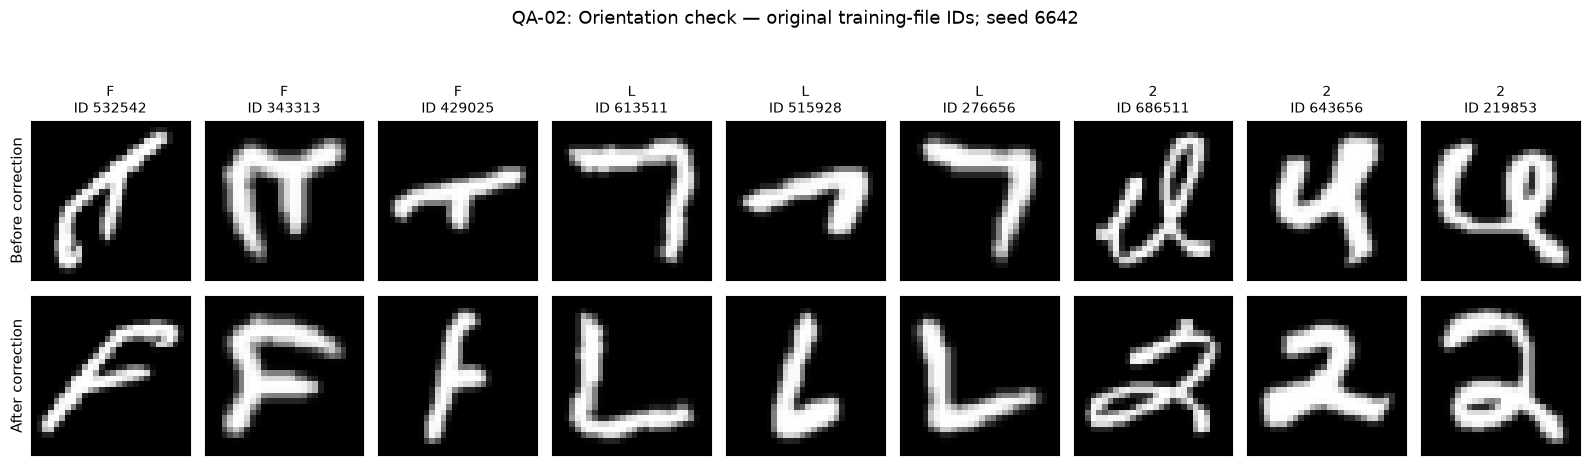

In [2]:
# Step 4: QA-02 — Visually check handwriting orientation.

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from google.colab import files

from mlreader import emnist

print("QA-02: Handwriting orientation")
print("Run time (UTC):", datetime.now(timezone.utc).isoformat())
print("Tested code revision:", CODE_COMMIT)

# Load original images before the orientation correction.
raw_images, raw_labels = emnist.load_raw("emnist-byclass-train")

# Use a fixed seed to select the same examples on later runs.
sample_seed = 6642
rng = np.random.default_rng(sample_seed)

sample_ids = []
sample_characters = []

for character in "FL2":
    label = emnist.CLASSES.index(character)
    candidates = np.flatnonzero(raw_labels == label)
    selected = rng.choice(candidates, size=3, replace=False)

    sample_ids.extend(int(index) for index in selected)
    sample_characters.extend([character] * 3)

before = raw_images[sample_ids].copy()

# Apply the project's orientation-correction function.
after = emnist.fix_orientation(before.copy())

assert after.shape == before.shape, (
    "FAIL: The correction changed the image dimensions."
)

# Compare each image before and after correction.
fig, axes = plt.subplots(2, len(sample_ids), figsize=(16, 5))

for column, (sample_id, character) in enumerate(
    zip(sample_ids, sample_characters)
):
    axes[0, column].imshow(
        before[column], cmap="gray", vmin=0, vmax=255
    )
    axes[1, column].imshow(
        after[column], cmap="gray", vmin=0, vmax=255
    )

    axes[0, column].set_title(
        f"{character}\nID {sample_id}", fontsize=10
    )

    for row in range(2):
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])

axes[0, 0].set_ylabel("Before correction", fontsize=11)
axes[1, 0].set_ylabel("After correction", fontsize=11)

fig.suptitle(
    f"QA-02: Orientation check — original training-file IDs; "
    f"seed {sample_seed}",
    fontsize=13
)
fig.tight_layout(rect=[0, 0, 1, 0.93])

# Save the comparison image as evidence.
evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)

image_path = evidence_dir / "QA02_Orientation_Check.png"
fig.savefig(image_path, dpi=160, bbox_inches="tight")

plt.show()
plt.close(fig)

print("\nSample IDs:", sample_ids)
print("Image dimensions preserved:", after.shape)
print("QA-02: Awaiting visual review before assigning Passed or Failed.")

del raw_images, raw_labels

files.download(str(image_path))

In [3]:
# Step 5: QA-03, Part A — Check training/validation membership.

import hashlib
import numpy as np
from datetime import datetime, timezone
from mlreader import emnist

print("QA-03, Part A: Training/validation membership")
print("Run time (UTC):", datetime.now(timezone.utc).isoformat())
print("Tested code revision:", CODE_COMMIT)

# Read the original training-file labels.
label_path = (
    emnist.EMNIST_DIR
    / "emnist-byclass-train-labels-idx1-ubyte.gz"
)
raw_labels = emnist.read_idx(label_path)

# Retain digits 0-9 and capital letters A-Z.
eligible_ids = np.flatnonzero(np.isin(raw_labels, np.arange(36)))
eligible_labels = raw_labels[eligible_ids]

assert emnist.SPLIT_SEED == 6642, "FAIL: Unexpected split seed."

# Run the project's splitting function twice.
train_a, val_a = emnist.train_val_indices(eligible_labels)
train_b, val_b = emnist.train_val_indices(eligible_labels)

assert np.array_equal(train_a, train_b), (
    "FAIL: Training membership changed between runs."
)
assert np.array_equal(val_a, val_b), (
    "FAIL: Validation membership changed between runs."
)
print("\nPASS: Both runs produced identical group membership.")

# Confirm that the groups share no example indices.
shared_indices = np.intersect1d(train_a, val_a)

assert len(shared_indices) == 0, (
    "FAIL: Some examples were assigned to both groups."
)
print("PASS: No example index appears in both groups.")

# Confirm that every eligible example is assigned exactly once.
combined_indices = np.concatenate([train_a, val_a])

assert np.array_equal(
    np.sort(combined_indices),
    np.arange(len(eligible_labels))
), "FAIL: Missing, repeated, or invalid example indices."

print("PASS: Every eligible example was assigned exactly once.")

# Record a fingerprint of each group's original example IDs.
for name, indices in [("train", train_a), ("val", val_a)]:
    source_ids = eligible_ids[indices]
    fingerprint = hashlib.sha256(
        source_ids.astype("<i8").tobytes()
    ).hexdigest()

    print(f"\n{name}: {len(indices):,} examples")
    print("Membership SHA-256:", fingerprint)

print("\nSplit seed:", emnist.SPLIT_SEED)
print("QA-03 PART A: PASSED")
print("QA-03 overall: still awaiting duplicate-image and generator checks.")

QA-03, Part A: Training/validation membership
Run time (UTC): 2026-10-07T14:49:46.000839+00:00
Tested code revision: 208a29981c65ce8121302a5fc05ee9e326aa2f44

PASS: Both runs produced identical group membership.
PASS: No example index appears in both groups.
PASS: Every eligible example was assigned exactly once.

train: 480,595 examples
Membership SHA-256: 4161d98aea258c6df1b5857340b77eaa2c522a4ae3936f0e2501434dcb569284

val: 53,398 examples
Membership SHA-256: 0b99fdba6516fae2d971392b7123140ba8c5e646bc597cd8a18ab16487b42335

Split seed: 6642
QA-03 PART A: PASSED
QA-03 overall: still awaiting duplicate-image and generator checks.


In [4]:
# Step 6: QA-03, Part B — Check for identical images across groups.

import json
from datetime import datetime, timezone
from google.colab import files
from mlreader import emnist

run_time = datetime.now(timezone.utc).isoformat()

print("QA-03, Part B: Exact duplicate images")
print("Run time (UTC):", run_time)
print("Tested code revision:", CODE_COMMIT)
print("\nLoading the three data groups...", flush=True)

split_images = {}

for name in ["train", "val", "test"]:
    images, labels = emnist.load_split(name)
    split_images[name] = images
    print(f"Loaded {name}: {len(images):,} images", flush=True)

# Find images in each query group that also appear
# in the corresponding reference group.
comparisons = {
    "test_in_train": ("train", "test"),
    "test_in_val": ("val", "test"),
    "val_in_train": ("train", "val")
}

matching_indices = {}

for check_name, (reference, query) in comparisons.items():
    print(f"\nChecking {check_name}...", flush=True)

    matches = emnist.duplicate_indices(
        split_images[reference],
        split_images[query]
    )

    matching_indices[check_name] = matches.tolist()
    print(f"Matching images: {len(matches):,}", flush=True)

# Record test-image positions needing exclusion from evaluation.
# This does not remove images or modify the generator.
excluded_test_indices = sorted(
    set(matching_indices["test_in_train"])
    | set(matching_indices["test_in_val"])
)

results = {
    "test_id": "QA-03 Part B",
    "run_time_utc": run_time,
    "code_commit": CODE_COMMIT,
    "method": (
        "Team duplicate checker: pixel hashes followed "
        "by exact array comparison"
    ),
    "counts": {
        name: len(indices)
        for name, indices in matching_indices.items()
    },
    "test_indices_also_in_train_or_val": excluded_test_indices,
    "index_reference": (
        "Positions in the arrays returned by emnist.load_split"
    ),
    "generator_exclusion_verified": False
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)

report_path = evidence_dir / "QA03_Duplicate_Check.json"
report_path.write_text(
    json.dumps(results, indent=2),
    encoding="utf-8"
)

print("\nDUPLICATE CHECK COMPLETE")
print(json.dumps(results["counts"], indent=2))
print(
    "Distinct test images also found in training or validation:",
    len(excluded_test_indices)
)
print("Test-array positions:", excluded_test_indices)
print("QA-03 overall remains pending review and generator verification.")

del split_images, images, labels

files.download(str(report_path))

QA-03, Part B: Exact duplicate images
Run time (UTC): 2026-10-07T14:49:46.177829+00:00
Tested code revision: 208a29981c65ce8121302a5fc05ee9e326aa2f44

Loading the three data groups...
Loaded train: 480,595 images
Loaded val: 53,398 images
Loaded test: 89,264 images

Checking test_in_train...
Matching images: 2

Checking test_in_val...
Matching images: 0

Checking val_in_train...
Matching images: 0

DUPLICATE CHECK COMPLETE
{
  "test_in_train": 2,
  "test_in_val": 0,
  "val_in_train": 0
}
Distinct test images also found in training or validation: 2
Test-array positions: [75979, 83597]
QA-03 overall remains pending review and generator verification.


In [5]:
# Step 7: QA-03, Part C — Verify the generator's eligible image pool.

import json
import numpy as np
from datetime import datetime, timezone
from google.colab import files
from mlreader import emnist
from mlreader.synthetic import load_leak_free_test_split

evidence_dir = PROJECT_DIR / "outputs" / "qa"
previous = json.loads(
    (evidence_dir / "QA03_Duplicate_Check.json").read_text()
)

assert previous["code_commit"] == CODE_COMMIT, (
    "Run Step 6 on the current code version first."
)

excluded_ids = previous["test_indices_also_in_train_or_val"]

print("QA-03, Part C: Generator image pool")
print("Tested code revision:", CODE_COMMIT)
print("Loading and checking the generator's pool...", flush=True)

pool_images, pool_labels, source_ids, excluded_count = (
    load_leak_free_test_split()
)
original_images, original_labels = emnist.load_split("test")

# Independently determine which test-image positions should remain.
expected_ids = np.setdiff1d(
    np.arange(len(original_labels)),
    np.array(excluded_ids, dtype=np.int64)
)

assert np.array_equal(source_ids, expected_ids), (
    "FAIL: Generator pool does not contain exactly the eligible test IDs."
)
assert excluded_count == len(excluded_ids), (
    "FAIL: Reported exclusion count does not match Step 6."
)
assert np.array_equal(pool_images, original_images[source_ids]), (
    "FAIL: Pool images do not match their recorded test-image IDs."
)
assert np.array_equal(pool_labels, original_labels[source_ids]), (
    "FAIL: Pool labels do not match the original test labels."
)
assert np.array_equal(np.unique(pool_labels), np.arange(36)), (
    "FAIL: The filtered pool is missing a required category."
)

pool_result = {
    "test_id": "QA-03 Part C",
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "original_test_images": len(original_labels),
    "eligible_test_images": len(source_ids),
    "excluded_test_indices": excluded_ids,
    "generator_pool_verified": True,
    "images_and_labels_match_test_sources": True,
    "all_36_categories_present": True,
    "generated_log_sources_verified": False
}

result_path = evidence_dir / "QA03_Generator_Pool_Check.json"
result_path.write_text(json.dumps(pool_result, indent=2))

print("\nPASS: Generator pool excludes exactly the identified duplicates.")
print("Eligible test images:", len(source_ids))
print("PASS: Images and labels match their original test sources.")
print("PASS: All 36 categories remain available.")
print("QA-03 overall: generated-log source check still pending.")

del pool_images, pool_labels, original_images, original_labels

files.download(str(result_path))

QA-03, Part C: Generator image pool
Tested code revision: 208a29981c65ce8121302a5fc05ee9e326aa2f44
Loading and checking the generator's pool...

PASS: Generator pool excludes exactly the identified duplicates.
Eligible test images: 89262
PASS: Images and labels match their original test sources.
PASS: All 36 categories remain available.
QA-03 overall: generated-log source check still pending.


In [6]:
# Step 8: QA-03, Part D — Check sources in a generated sample log.

import json
import subprocess
import sys
import numpy as np
from datetime import datetime, timezone
from google.colab import files
from mlreader import emnist

evidence_dir = PROJECT_DIR / "outputs" / "qa"
pool_check = json.loads(
    (evidence_dir / "QA03_Generator_Pool_Check.json").read_text()
)

assert pool_check["code_commit"] == CODE_COMMIT
assert pool_check["generator_pool_verified"]

generated_dir = evidence_dir / "qa03_generated_logs"

command = [
    sys.executable, "scripts/generate_synthetic_logs.py",
    "--count", "1",
    "--quality", "clean",
    "--rows", "6",
    "--seed", "6642",
    "--output", str(generated_dir)
]

print("Generating one sample log...", flush=True)
subprocess.run(command, cwd=PROJECT_DIR, check=True)

manifest = json.loads((generated_dir / "manifest.json").read_text())
assert len(manifest) == 1, "FAIL: Expected one generated log."

record = json.loads(
    (generated_dir / manifest[0]["truth_file"]).read_text()
)
image_path = generated_dir / manifest[0]["image"]
assert image_path.is_file() and image_path.stat().st_size > 0

# Read the original test labels and apply the loader's category filter.
raw_labels = emnist.read_idx(
    emnist.EMNIST_DIR / "emnist-byclass-test-labels-idx1-ubyte.gz"
)
test_labels = raw_labels[np.isin(raw_labels, np.arange(36))]
excluded = set(pool_check["excluded_test_indices"])

# Every expected character position must have exactly one source record.
expected_positions = {
    (field, position)
    for field, value in record["truth"]["fields"].items()
    for position in range(len(value))
}
sources = record["character_sources"]
actual_positions = {
    (source["field"], source["position"]) for source in sources
}

assert actual_positions == expected_positions
assert len(sources) == len(expected_positions)
assert record["excluded_exact_source_duplicates"] == len(excluded)

for source in sources:
    index = source["test_image_index"]
    assert source["source_split"] == "EMNIST ByClass test"
    assert 0 <= index < len(test_labels)
    assert index not in excluded, "FAIL: An excluded image was selected."

    expected_character = record["truth"]["fields"][
        source["field"]
    ][source["position"]]

    assert source["label"] == expected_character
    assert emnist.CLASSES[int(test_labels[index])] == expected_character

result = {
    "test_id": "QA-03 Part D",
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "seed": 6642,
    "condition": "clean",
    "logs_checked": len(manifest),
    "character_sources_checked": len(sources),
    "excluded_test_indices": sorted(excluded),
    "all_sources_are_eligible_test_images": True,
    "all_source_labels_match_truth": True,
    "every_expected_position_has_one_source": True,
    "status": "Passed",
    "scope": "Recorded character sources for one generated six-row log.",
    "generated_log_record": record
}

result_path = evidence_dir / "QA03_Generator_Source_Check.json"
result_path.write_text(json.dumps(result, indent=2))

print("\nQA-03 PART D: PASSED")
print("Character sources checked:", len(sources))
print("All recorded sources are eligible test images.")
print("No excluded duplicate was selected.")
print("All source labels match the intended characters.")

files.download(str(result_path))

Generating one sample log...

QA-03 PART D: PASSED
Character sources checked: 148
All recorded sources are eligible test images.
No excluded duplicate was selected.
All source labels match the intended characters.


In [7]:
# Step 9: QA-06 — Check field assembly and leading zeros.

import json
from datetime import datetime, timezone
from google.colab import files
from mlreader.fields import assemble_field

expected_fields = {
    "header.employee_id": "RC5107",
    "header.week_ending": "092726",
    "rows.1.date": "0921",
    "rows.1.client": "KMR",
    "rows.1.odometer_start": "048213",
    "rows.1.odometer_end": "048238",
    "rows.1.miles": "025",
    "footer.total_miles": "0038"
}

observations = []

print("QA-06: Field assembly and leading zeros")
print("Tested code revision:", CODE_COMMIT)

for field_name, expected in expected_fields.items():
    # These are controlled test inputs, not model predictions.
    supplied_characters = [
        {"character": character, "confidence": 0.99}
        for character in expected
    ]

    assembled = assemble_field(field_name, supplied_characters)

    assert assembled["raw_value"] == expected, (
        f"FAIL: Character order changed in {field_name}."
    )
    assert assembled["value"] == expected, (
        f"FAIL: Field value changed in {field_name}."
    )
    assert assembled["complete"], (
        f"FAIL: {field_name} was incorrectly marked incomplete."
    )

    observations.append({
        "field": field_name,
        "supplied_characters": list(expected),
        "expected": expected,
        "actual": assembled["value"],
        "status": "Passed"
    })
    print(f"PASS: {field_name} → {assembled['value']}")

qa06_result = {
    "test_id": "QA-06",
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "status": "Passed",
    "scope": "Eight controlled field-assembly cases; not model accuracy.",
    "injected_confidence": 0.99,
    "results": observations
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)
result_path = evidence_dir / "QA06_Field_Assembly_Check.json"
result_path.write_text(json.dumps(qa06_result, indent=2))

print("\nQA-06 RESULT: PASSED")
files.download(str(result_path))

QA-06: Field assembly and leading zeros
Tested code revision: 208a29981c65ce8121302a5fc05ee9e326aa2f44
PASS: header.employee_id → RC5107
PASS: header.week_ending → 092726
PASS: rows.1.date → 0921
PASS: rows.1.client → KMR
PASS: rows.1.odometer_start → 048213
PASS: rows.1.odometer_end → 048238
PASS: rows.1.miles → 025
PASS: footer.total_miles → 0038

QA-06 RESULT: PASSED


In [8]:
# Step 10: QA-08, QA-11 and QA-19 — Validate baseline B1.

import copy
import json
from datetime import date, datetime, timezone
from decimal import Decimal
from google.colab import files
from mlreader.fields import assemble_field
from mlreader.validation import validate_document

# Build controlled field inputs, without using model predictions.
def qa_field(name, value):
    return assemble_field(
        name,
        [{"character": char, "confidence": 0.99} for char in value]
    )

def qa_baseline():
    document = {
        "header": {
            "employee_id": qa_field("header.employee_id", "RC5107"),
            "week_ending": qa_field("header.week_ending", "092726")
        },
        "rows": [],
        "footer": {
            "total_miles": qa_field("footer.total_miles", "0038")
        }
    }

    field_names = [
        "date", "client", "odometer_start", "odometer_end", "miles"
    ]
    row_values = [
        ["0921", "KMR", "048213", "048238", "025"],
        ["0921", "PDL", "048238", "048251", "013"]
    ]

    for row_number, values in enumerate(row_values, start=1):
        document["rows"].append({
            "row_number": row_number,
            "fields": {
                name: qa_field(f"rows.{row_number}.{name}", value)
                for name, value in zip(field_names, values)
            }
        })

    return document

# Made-up reference records matching the matrix's baseline B1.
qa_references = {
    "employees": ["RC5107"],
    "visit_schedule": {
        "RC5107": {"2026-09-21": ["KMR", "PDL"]}
    }
}
qa_date = date(2026, 10, 5)
qa_policy = json.loads(
    (PROJECT_DIR / "configs" / "reader_policy.json").read_text()
)

baseline_input = qa_baseline()
checked = validate_document(
    copy.deepcopy(baseline_input),
    qa_references,
    qa_policy,
    today=qa_date
)

header_checks = checked["validation"]["header_checks"]
row_results = [row["validation"] for row in checked["rows"]]

# QA-08: employee and client/date reference checks.
assert header_checks["employee_exists"]
assert all(
    row["checks"]["client_on_visit_schedule"]
    for row in row_results
)
print("QA-08 PASSED: Employee and both scheduled clients match.")

# QA-11: valid dates under the fixed evaluation date.
assert all(header_checks[key] for key in [
    "week_ending_format",
    "week_ending_is_sunday",
    "week_ending_within_last_60_days"
])
assert all(
    row["checks"]["trip_date_format_and_in_week"]
    for row in row_results
)
print("QA-11 PASSED: Week ending and both trip dates are valid.")

# QA-19: mileage, continuity, total and reimbursement.
assert qa_policy["reimbursement_rate"] == 0.62
assert all(
    row["checks"][key]
    for row in row_results
    for key in [
        "odometer_end_after_start",
        "odometer_continuity",
        "miles_equals_odometer_difference"
    ]
)
assert [row["miles_value"] for row in row_results] == [25, 13]

total = checked["validation"]["weekly_total"]
assert total["passed"]
assert total["written_total"] == 38
assert total["sum_of_written_row_miles"] == 38

amounts = [row["reimbursement"] for row in row_results]
assert amounts == ["15.50", "8.06"]
combined_amount = sum(Decimal(amount) for amount in amounts)
assert combined_amount == Decimal("23.56")

print("QA-19 PASSED: 25 + 13 = 38 miles.")
print("Reimbursements: $15.50 + $8.06 = $23.56.")

baseline_result = {
    "test_ids": ["QA-08", "QA-11", "QA-19"],
    "status": "Passed",
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "evaluation_date": qa_date.isoformat(),
    "fixture": "B1",
    "scope": "Controlled reference, date and arithmetic checks.",
    "injected_confidence": 0.99,
    "policy_note": "Existing prototype settings; not threshold approval.",
    "references": qa_references,
    "policy": qa_policy,
    "input": baseline_input,
    "actual_output": checked,
    "combined_reimbursement": str(combined_amount)
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
result_path = evidence_dir / "QA_Baseline_Validation_Check.json"
result_path.write_text(json.dumps(baseline_result, indent=2))

files.download(str(result_path))

QA-08 PASSED: Employee and both scheduled clients match.
QA-11 PASSED: Week ending and both trip dates are valid.
QA-19 PASSED: 25 + 13 = 38 miles.
Reimbursements: $15.50 + $8.06 = $23.56.


In [9]:
# Step 11: QA-09 and QA-10 — Reject unknown reference values.

import copy
import json
from datetime import datetime, timezone
from google.colab import files
from mlreader.validation import validate_document

reference_results = []

# QA-09: Change only the employee ID.
employee_input = qa_baseline()
employee_input["header"]["employee_id"] = qa_field(
    "header.employee_id", "ZZ9999"
)

employee_output = validate_document(
    copy.deepcopy(employee_input),
    qa_references,
    qa_policy,
    today=qa_date
)

assert not employee_output["validation"]["header_checks"]["employee_exists"]
assert all(
    row["validation"]["route"] == "needs_review"
    for row in employee_output["rows"]
)
assert all(
    "header_employee_exists" in row["validation"]["route_reasons"]
    for row in employee_output["rows"]
)

reference_results.append({
    "test_id": "QA-09",
    "status": "Passed",
    "expected": "Unknown employee is flagged; affected rows need review.",
    "input": employee_input,
    "actual_output": employee_output
})
print("QA-09 PASSED: Unknown employee flagged; both rows need review.")

# QA-10: Start fresh and change only the first row's client.
client_input = qa_baseline()
client_input["rows"][0]["fields"]["client"] = qa_field(
    "rows.1.client", "XYZ"
)

client_output = validate_document(
    copy.deepcopy(client_input),
    qa_references,
    qa_policy,
    today=qa_date
)

first_row = client_output["rows"][0]["validation"]
second_row = client_output["rows"][1]["validation"]

assert not first_row["checks"]["client_on_visit_schedule"]
assert first_row["route"] == "needs_review"
assert "client_on_visit_schedule" in first_row["route_reasons"]

# Confirm that the unchanged row still passes its client lookup.
assert second_row["checks"]["client_on_visit_schedule"]

reference_results.append({
    "test_id": "QA-10",
    "status": "Passed",
    "expected": "Unscheduled client is flagged; first row needs review.",
    "input": client_input,
    "actual_output": client_output
})
print("QA-10 PASSED: Unscheduled client flagged; first row needs review.")

reference_report = {
    "test_ids": ["QA-09", "QA-10"],
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "evaluation_date": qa_date.isoformat(),
    "fixture": "B1 with one changed field per case",
    "references": qa_references,
    "policy": qa_policy,
    "scope": "Controlled reference failures under the current prototype policy.",
    "results": reference_results
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
result_path = evidence_dir / "QA_Invalid_Reference_Check.json"
result_path.write_text(json.dumps(reference_report, indent=2))

files.download(str(result_path))

QA-09 PASSED: Unknown employee flagged; both rows need review.
QA-10 PASSED: Unscheduled client flagged; first row needs review.


In [10]:
# Step 12 — QA-12 and QA-13: Invalid trip dates

import copy
import json
from datetime import date, datetime, timezone
from google.colab import files
from mlreader.validation import validate_document

date_results = []

for test_id, invalid_date in [
    ("QA-12", "0230"),
    ("QA-13", "0928"),
]:
    test_input = qa_baseline()
    test_references = copy.deepcopy(qa_references)
    evaluation_date = qa_date

    if test_id == "QA-12":
        # Valid starting example: February 28 in the week ending March 1.
        evaluation_date = date(2026, 3, 2)

        test_input["header"]["week_ending"] = qa_field(
            "header.week_ending", "030126"
        )
        test_input["rows"] = test_input["rows"][:1]
        test_input["rows"][0]["fields"]["date"] = qa_field(
            "rows.1.date", "0228"
        )
        test_input["footer"]["total_miles"] = qa_field(
            "footer.total_miles", "0025"
        )
        test_references["visit_schedule"]["RC5107"] = {
            "2026-02-28": ["KMR"]
        }
        expected = "February 30 is rejected and the row needs review."

    else:
        # Include a matching visit so the outside-week date is intentional.
        test_references["visit_schedule"]["RC5107"]["2026-09-28"] = [
            "KMR"
        ]
        expected = (
            "September 28 is rejected for the week ending September 27, "
            "and the row needs review."
        )

    # Confirm that the starting example passes.
    control_input = copy.deepcopy(test_input)
    control_output = validate_document(
        copy.deepcopy(control_input),
        test_references,
        qa_policy,
        today=evaluation_date,
    )
    assert control_output["validation"]["outcome"] == "auto_post", (
        f"{test_id}: The valid starting example did not pass."
    )

    # Change only the first row's date.
    test_input["rows"][0]["fields"]["date"] = qa_field(
        "rows.1.date", invalid_date
    )

    actual_output = validate_document(
        copy.deepcopy(test_input),
        test_references,
        qa_policy,
        today=evaluation_date,
    )
    first_row = actual_output["rows"][0]
    validation = first_row["validation"]

    assert validation["checks"]["trip_date_format_and_in_week"] is False
    assert validation["route"] == "needs_review"
    assert "trip_date_format_and_in_week" in validation["route_reasons"]
    assert first_row["fields"]["date"]["value"] == invalid_date

    date_results.append({
        "test_id": test_id,
        "status": "Passed",
        "expected": expected,
        "evaluation_date": evaluation_date.isoformat(),
        "references": test_references,
        "valid_control_input": control_input,
        "valid_control_output": control_output,
        "input": test_input,
        "actual_output": actual_output,
    })

    print(f"{test_id}: Passed")
    print(f"  Entered date: {invalid_date}")
    print(f"  Route: {validation['route']}")
    print(f"  Reasons: {validation['route_reasons']}")

evidence = {
    "test_ids": ["QA-12", "QA-13"],
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "policy": qa_policy,
    "scope": (
        "Controlled date validation with injected character confidence "
        "of 0.99; not a handwriting recognition accuracy test."
    ),
    "implementation_note": (
        "The current validator combines calendar validity and week "
        "membership in one check. When that check fails, its client "
        "schedule check also fails because no valid trip date is available."
    ),
    "results": date_results,
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)
evidence_path = evidence_dir / "QA_Invalid_Date_Check.json"
evidence_path.write_text(json.dumps(evidence, indent=2), encoding="utf-8")

print(f"\nSaved: {evidence_path.name}")
files.download(str(evidence_path))

QA-12: Passed
  Entered date: 0230
  Route: needs_review
  Reasons: ['trip_date_format_and_in_week', 'client_on_visit_schedule']
QA-13: Passed
  Entered date: 0928
  Route: needs_review
  Reasons: ['trip_date_format_and_in_week', 'client_on_visit_schedule']

Saved: QA_Invalid_Date_Check.json


In [11]:
# Step 13 — QA-15 and QA-16: Odometer rules

import copy
import json
from datetime import datetime, timezone
from google.colab import files
from mlreader.validation import validate_document

odometer_results = []

cases = [
    ("QA-15", "Ending equals starting", "048213", False),
    ("QA-15", "Ending below starting", "048212", False),
    ("QA-16", "Next starting equals previous ending", "048238", True),
    ("QA-16", "Next starting below previous ending", "048237", False),
]

for test_id, case_name, reading, should_accept in cases:
    test_input = qa_baseline()

    if test_id == "QA-15":
        # Use one trip to avoid involving the next trip's starting reading.
        test_input["rows"] = test_input["rows"][:1]
        test_input["footer"]["total_miles"] = qa_field(
            "footer.total_miles", "0025"
        )

    # Verify the valid starting example before changing it.
    control_input = copy.deepcopy(test_input)
    control_output = validate_document(
        copy.deepcopy(control_input),
        qa_references,
        qa_policy,
        today=qa_date,
    )
    assert control_output["validation"]["outcome"] == "auto_post"

    if test_id == "QA-15":
        test_input["rows"][0]["fields"]["odometer_end"] = qa_field(
            "rows.1.odometer_end", reading
        )
        row_index = 0
        check_name = "odometer_end_after_start"

    else:
        test_input["rows"][1]["fields"]["odometer_start"] = qa_field(
            "rows.2.odometer_start", reading
        )

        # Keep the second trip's mileage and the weekly total consistent.
        second_trip_miles = 48251 - int(reading)
        test_input["rows"][1]["fields"]["miles"] = qa_field(
            "rows.2.miles", f"{second_trip_miles:03d}"
        )
        test_input["footer"]["total_miles"] = qa_field(
            "footer.total_miles", f"{25 + second_trip_miles:04d}"
        )
        row_index = 1
        check_name = "odometer_continuity"

    actual_output = validate_document(
        copy.deepcopy(test_input),
        qa_references,
        qa_policy,
        today=qa_date,
    )

    validation = actual_output["rows"][row_index]["validation"]
    expected_route = "auto_post" if should_accept else "needs_review"

    assert validation["checks"][check_name] is should_accept
    assert validation["route"] == expected_route
    assert actual_output["validation"]["weekly_total"]["passed"] is True

    if not should_accept:
        assert check_name in validation["route_reasons"]

    odometer_results.append({
        "test_id": test_id,
        "case": case_name,
        "status": "Passed",
        "expected_check": check_name,
        "expected_check_result": should_accept,
        "expected_route": expected_route,
        "valid_control_input": control_input,
        "valid_control_output": control_output,
        "input": test_input,
        "actual_output": actual_output,
    })

    print(f"{test_id} — {case_name}: Passed")
    print(f"  Route: {validation['route']}")
    print(f"  Reasons: {validation['route_reasons']}")

evidence = {
    "test_ids": ["QA-15", "QA-16"],
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "evaluation_date": qa_date.isoformat(),
    "references": qa_references,
    "policy": qa_policy,
    "scope": (
        "Controlled odometer validation with injected character confidence "
        "of 0.99; not a handwriting recognition accuracy test."
    ),
    "implementation_note": (
        "QA-15 keeps the original written mileage, so changing the ending "
        "odometer also produces a mileage-difference warning. QA-16 adjusts "
        "written mileage and the total to isolate the continuity rule."
    ),
    "results": odometer_results,
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)
evidence_path = evidence_dir / "QA_Odometer_Check.json"
evidence_path.write_text(json.dumps(evidence, indent=2), encoding="utf-8")

print(f"\nSaved: {evidence_path.name}")
files.download(str(evidence_path))

QA-15 — Ending equals starting: Passed
  Route: needs_review
  Reasons: ['odometer_end_after_start', 'miles_equals_odometer_difference']
QA-15 — Ending below starting: Passed
  Route: needs_review
  Reasons: ['odometer_end_after_start', 'miles_equals_odometer_difference']
QA-16 — Next starting equals previous ending: Passed
  Route: auto_post
  Reasons: []
QA-16 — Next starting below previous ending: Passed
  Route: needs_review
  Reasons: ['odometer_continuity']

Saved: QA_Odometer_Check.json


In [12]:
# Step 14 — QA-17, QA-18, and QA-20: Mileage discrepancies

import copy
import json
from datetime import datetime, timezone
from google.colab import files
from mlreader.validation import validate_document

# QA-17 and QA-20 share the same controlled example.
mileage_input = qa_baseline()
mileage_input["rows"] = mileage_input["rows"][:1]

for field_name, value in [
    ("odometer_start", "048390"),
    ("odometer_end", "048437"),
    ("miles", "042"),
]:
    mileage_input["rows"][0]["fields"][field_name] = qa_field(
        f"rows.1.{field_name}", value
    )

# Match the written row miles so only the odometer discrepancy is tested.
mileage_input["footer"]["total_miles"] = qa_field(
    "footer.total_miles", "0042"
)

mileage_output = validate_document(
    copy.deepcopy(mileage_input),
    qa_references,
    qa_policy,
    today=qa_date,
)

row = mileage_output["rows"][0]
validation = row["validation"]
odometer_difference = (
    int(row["fields"]["odometer_end"]["value"])
    - int(row["fields"]["odometer_start"]["value"])
)

# QA-17: Detect the mismatch without silently replacing the written miles.
assert odometer_difference == 47
assert row["fields"]["miles"]["raw_value"] == "042"
assert row["fields"]["miles"]["value"] == "042"
assert validation["checks"]["miles_equals_odometer_difference"] is False
assert validation["route"] == "needs_review"
assert "miles_equals_odometer_difference" in validation["route_reasons"]
assert mileage_output["validation"]["weekly_total"]["passed"] is True

print("QA-17: Passed — written 42 preserved; calculated 47; review required.")

# QA-20: High confidence must not override the failed mileage rule.
assert all(
    character["confidence"] == 0.99
    for field in row["fields"].values()
    for character in field["characters"]
)
assert all(
    result["passed"]
    for result in validation["confidence_checks"].values()
)
assert validation["route"] == "needs_review"

print("QA-20: Passed — high confidence did not override the mileage error.")

# QA-18: Correct trip miles, but an incorrect written total.
total_input = qa_baseline()
total_input["footer"]["total_miles"] = qa_field(
    "footer.total_miles", "0039"
)

total_output = validate_document(
    copy.deepcopy(total_input),
    qa_references,
    qa_policy,
    today=qa_date,
)

total_check = total_output["validation"]["weekly_total"]

assert total_check["written_total"] == 39
assert total_check["sum_of_written_row_miles"] == 38
assert total_check["passed"] is False
assert total_output["footer"]["total_miles"]["value"] == "0039"

# Each trip is individually valid.
assert all(
    all(row["validation"]["checks"].values())
    for row in total_output["rows"]
)

# Under the current prototype policy, the total mismatch sends both to review.
assert all(
    row["validation"]["route"] == "needs_review"
    and "weekly_total_matches" in row["validation"]["route_reasons"]
    for row in total_output["rows"]
)

print("QA-18: Passed — written total 39 differs from sum 38; review required.")

evidence = {
    "test_ids": ["QA-17", "QA-18", "QA-20"],
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "evaluation_date": qa_date.isoformat(),
    "references": qa_references,
    "policy": qa_policy,
    "scope": (
        "Controlled mileage validation with injected confidence of 0.99. "
        "These tests do not measure handwriting recognition accuracy "
        "or establish approved confidence thresholds."
    ),
    "policy_note": (
        "QA-18 records the current prototype behavior of routing both rows "
        "for review after a total mismatch. Final routing-policy approval "
        "remains separate."
    ),
    "results": [
        {
            "test_id": "QA-17",
            "status": "Passed",
            "expected": "Preserve written 042; flag difference from 47.",
            "calculated_odometer_difference": odometer_difference,
            "input": mileage_input,
            "actual_output": mileage_output,
        },
        {
            "test_id": "QA-18",
            "status": "Passed",
            "expected": "Flag written total 39 versus actual sum 38.",
            "input": total_input,
            "actual_output": total_output,
        },
        {
            "test_id": "QA-20",
            "status": "Passed",
            "expected": "High confidence cannot override a mileage mismatch.",
            "injected_character_confidence": 0.99,
            "input": mileage_input,
            "actual_output": mileage_output,
        },
    ],
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)
evidence_path = evidence_dir / "QA_Mileage_Discrepancy_Check.json"
evidence_path.write_text(json.dumps(evidence, indent=2), encoding="utf-8")

print(f"\nSaved: {evidence_path.name}")
files.download(str(evidence_path))

QA-17: Passed — written 42 preserved; calculated 47; review required.
QA-20: Passed — high confidence did not override the mileage error.
QA-18: Passed — written total 39 differs from sum 38; review required.

Saved: QA_Mileage_Discrepancy_Check.json


In [13]:
# Step 15 — QA-07: Allowed letters and numbers

import json
import numpy as np
from datetime import datetime, timezone
from google.colab import files
from mlreader.classifier import EMNISTMLP
from mlreader.emnist import CLASSES

# Supply controlled scores while using the project's actual predict method.
# This test does not load trained model weights or modify project files.
class ControlledScoresReader(EMNISTMLP):
    def __init__(self, scores):
        self.test_scores = np.asarray(scores, dtype=np.float64)

    def _probabilities(self, image):
        return self.test_scores.copy()

charset_results = []
placeholder_image = np.zeros((28, 28), dtype=np.uint8)

for allowed, highest_character, expected_character in [
    ("digit", "O", "0"),
    ("letter", "0", "O"),
]:
    scores = np.zeros(len(CLASSES), dtype=np.float64)
    scores[CLASSES.index(highest_character)] = 0.60
    scores[CLASSES.index(expected_character)] = 0.40

    test_reader = ControlledScoresReader(scores)

    # Without a restriction, the higher-scoring character should win.
    unrestricted = test_reader.predict(
        placeholder_image, allowed="all"
    )
    assert unrestricted["character"] == highest_character

    # Apply the field's character restriction.
    restricted = test_reader.predict(
        placeholder_image, allowed=allowed
    )

    permitted = set(
        "0123456789"
        if allowed == "digit"
        else "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    )

    assert restricted["character"] == expected_character
    assert set(restricted["class_probabilities"]) == permitted
    assert all(
        item["character"] in permitted
        for item in restricted["top_alternatives"]
    )

    charset_results.append({
        "test_id": "QA-07",
        "allowed_type": allowed,
        "status": "Passed",
        "supplied_scores": {
            character: float(scores[index])
            for index, character in enumerate(CLASSES)
        },
        "expected_character": expected_character,
        "unrestricted_output": unrestricted,
        "restricted_output": restricted,
    })

    print(f"QA-07 — {allowed}-only field: Passed")
    print(f"  Unrestricted answer: {unrestricted['character']}")
    print(f"  Restricted answer: {restricted['character']}")

evidence = {
    "test_ids": ["QA-07"],
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "scope": (
        "Controlled test of EMNISTMLP.predict character restrictions. "
        "Scores are supplied by the test; no trained model is evaluated."
    ),
    "implementation_note": (
        "The image is a placeholder because score generation is replaced "
        "for this test. Returned confidence is renormalized over allowed "
        "characters and is not measured recognition accuracy."
    ),
    "results": charset_results,
}

evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)
evidence_path = evidence_dir / "QA07_Allowed_Characters_Check.json"
evidence_path.write_text(json.dumps(evidence, indent=2), encoding="utf-8")

print(f"\nSaved: {evidence_path.name}")
files.download(str(evidence_path))

QA-07 — digit-only field: Passed
  Unrestricted answer: O
  Restricted answer: 0
QA-07 — letter-only field: Passed
  Unrestricted answer: 0
  Restricted answer: O

Saved: QA07_Allowed_Characters_Check.json


Checks passed: six non-empty crops in order.
QA-04 remains pending until the images are visually reviewed.


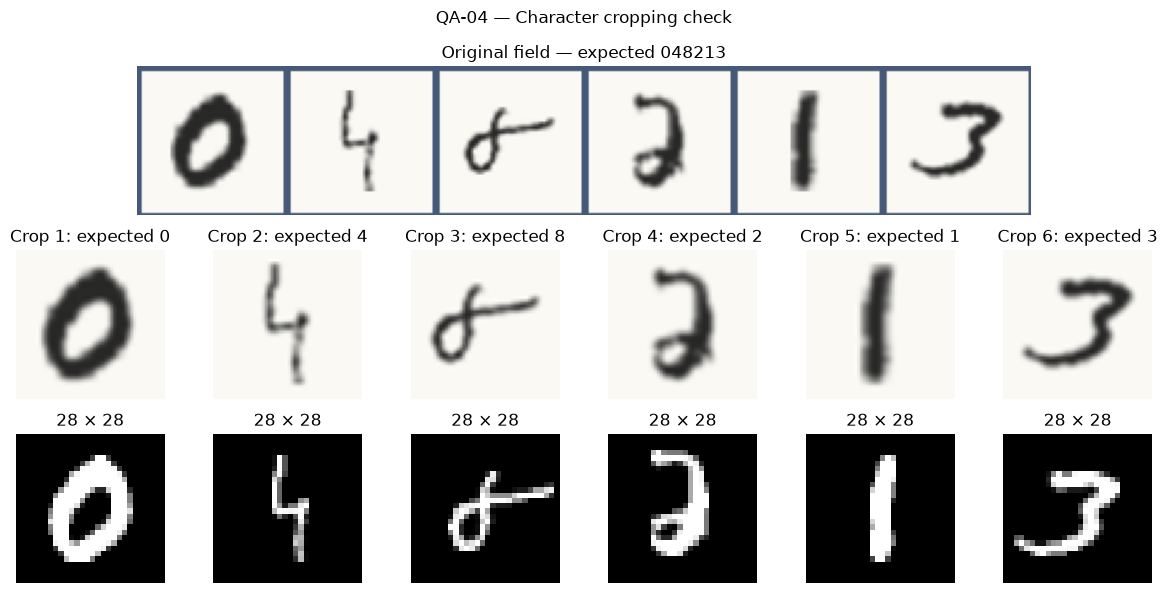

In [14]:
# Step 16 — QA-04: Extract six characters from an odometer field

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from google.colab import files
from mlreader.emnist import load_split
from mlreader.layout import FIELDS
from mlreader.synthetic import draw_split_characters, capture_page
from mlreader.registration import register_page, extract_cells

evidence_dir = PROJECT_DIR / "outputs" / "qa"
evidence_dir.mkdir(parents=True, exist_ok=True)

# Reuse the exclusions already verified in QA-03.
pool_check = json.loads(
    (evidence_dir / "QA03_Generator_Pool_Check.json").read_text()
)
assert pool_check["code_commit"] == CODE_COMMIT
assert pool_check["generator_pool_verified"] is True

test_images, test_labels = load_split("test")
eligible_ids = np.setdiff1d(
    np.arange(len(test_labels)),
    pool_check["excluded_test_indices"],
)

qa04_field = "rows.1.odometer_start"
qa04_expected = "048213"
qa04_seed = 6642

# Render held-out EMNIST characters into this field.
qa04_page, qa04_sources = draw_split_characters(
    {"fields": {qa04_field: qa04_expected}},
    test_images[eligible_ids],
    test_labels[eligible_ids],
    np.random.default_rng(qa04_seed),
    source_split="test", source_indices=eligible_ids,
)

assert len(qa04_sources) == 6
assert "".join(s["label"] for s in qa04_sources) == qa04_expected
assert all(
    s["test_image_index"] not in pool_check["excluded_test_indices"]
    for s in qa04_sources
)

del test_images, test_labels

# Create a clean simulated photograph, then use the project's extraction.
qa04_capture, _ = capture_page(
    qa04_page, condition="clean", seed=qa04_seed
)
qa04_input_path = evidence_dir / "QA04_Input.png"
assert cv2.imwrite(str(qa04_input_path), qa04_capture)

qa04_registration = register_page(qa04_input_path)
assert qa04_registration.ok, qa04_registration.reason

qa04_cells = extract_cells(qa04_registration.image)[qa04_field]

assert len(qa04_cells) == 6
assert [cell.position for cell in qa04_cells] == list(range(6))
assert all(cell.extraction_status == "ok" for cell in qa04_cells)
assert all(cell.normalized.shape == (28, 28) for cell in qa04_cells)

# Show the original field and its extracted characters.
locations = FIELDS[qa04_field]
left, top = locations[0].rect[:2]
right, bottom = locations[-1].rect[2:]
original_strip = qa04_page[top:bottom, left:right]

fig = plt.figure(figsize=(12, 6))
grid = fig.add_gridspec(3, 6)

ax = fig.add_subplot(grid[0, :])
ax.imshow(cv2.cvtColor(original_strip, cv2.COLOR_BGR2RGB))
ax.set_title("Original field — expected 048213")
ax.axis("off")

for index, cell in enumerate(qa04_cells):
    ax = fig.add_subplot(grid[1, index])
    ax.imshow(cv2.cvtColor(cell.image, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Crop {index + 1}: expected {qa04_expected[index]}")
    ax.axis("off")

    ax = fig.add_subplot(grid[2, index])
    ax.imshow(cell.normalized, cmap="gray", vmin=0, vmax=255)
    ax.set_title("28 × 28")
    ax.axis("off")

fig.suptitle("QA-04 — Character cropping check")
fig.tight_layout()

qa04_image_path = evidence_dir / "QA04_Character_Crops.png"
fig.savefig(qa04_image_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

qa04_evidence = {
    "test_id": "QA-04",
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "seed": qa04_seed,
    "condition": "clean",
    "field": qa04_field,
    "expected_value": qa04_expected,
    "input_image": qa04_input_path.name,
    "comparison_image": qa04_image_path.name,
    "character_sources": qa04_sources,
    "registration_method": qa04_registration.method,
    "checks": "Passed",
    "overall_status": "Pending visual review",
    "scope": "One six-digit field; extraction only, no model recognition.",
    "cells": [
        {
            "position": cell.position,
            "expected_character": qa04_expected[cell.position],
            "rectangle": list(cell.rect),
            "extraction_status": cell.extraction_status,
            "ink_pixels": int(cell.ink_pixels),
            "normalized_shape": list(cell.normalized.shape),
        }
        for cell in qa04_cells
    ],
}

qa04_json_path = evidence_dir / "QA04_Character_Crops_Check.json"
qa04_json_path.write_text(
    json.dumps(qa04_evidence, indent=2), encoding="utf-8"
)

print("Checks passed: six non-empty crops in order.")
print("QA-04 remains pending until the images are visually reviewed.")

files.download(str(qa04_image_path))
files.download(str(qa04_json_path))

Missing-character check: Passed
Assembled field: 04?213
Failure category: cell_extraction
Row route: needs_review
QA-05: Passed for the specified missing-character variant.


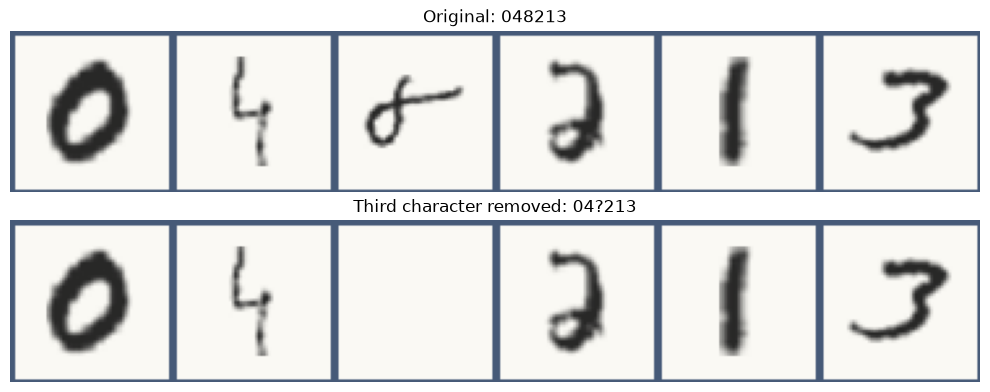

In [15]:
# Step 17 — QA-05: Missing-character handling

import copy
import json
import cv2
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from google.colab import files
from mlreader.synthetic import load_template, capture_page
from mlreader.registration import register_page, extract_cells
from mlreader.pipeline import _predict_cell
from mlreader.fields import assemble_field
from mlreader.validation import validate_document

# Use the image created in Step 16.
qa05_page = qa04_page.copy()
missing_position = 2  # Third character: the 8.

location = FIELDS[qa04_field][missing_position]
left, top, right, bottom = location.rect

# Restore this box from the blank template, removing only its character.
blank_template = load_template()
qa05_page[top:bottom, left:right] = blank_template[
    top:bottom, left:right
]

qa05_capture, _ = capture_page(
    qa05_page, condition="clean", seed=6642
)
qa05_input_path = evidence_dir / "QA05_Missing_Character_Input.png"
assert cv2.imwrite(str(qa05_input_path), qa05_capture)

registration = register_page(qa05_input_path)
assert registration.ok, registration.reason

missing_cells = extract_cells(registration.image)[qa04_field]

assert len(missing_cells) == 6
assert missing_cells[missing_position].extraction_status == "empty"
assert all(
    cell.extraction_status == "ok"
    for index, cell in enumerate(missing_cells)
    if index != missing_position
)

# Use the project's failure handling for the empty box.
missing_prediction = _predict_cell(
    missing_cells[missing_position], model=None
)
assert missing_prediction["character"] is None
assert missing_prediction["failure_kind"] == "cell_extraction"

# Supply correct readings for the other five positions.
predictions = [
    missing_prediction if index == missing_position else {
        "character": character,
        "confidence": 0.99,
        "extraction_status": "ok",
        "failure_kind": None,
    }
    for index, character in enumerate(qa04_expected)
]

missing_field = assemble_field(qa04_field, predictions)
assert missing_field["raw_value"] == "04?213"
assert missing_field["complete"] is False

test_input = qa_baseline()
test_input["rows"][0]["fields"]["odometer_start"] = missing_field

actual_output = validate_document(
    copy.deepcopy(test_input),
    qa_references,
    qa_policy,
    today=qa_date,
)
row_result = actual_output["rows"][0]["validation"]

assert row_result["route"] == "needs_review"
assert "odometer_start_confidence" in row_result["route_reasons"]

# Show the original and deliberately altered field.
locations = FIELDS[qa04_field]
x0, y0 = locations[0].rect[:2]
x1, y1 = locations[-1].rect[2:]

fig, axes = plt.subplots(2, 1, figsize=(10, 4))
for ax, page, title in [
    (axes[0], qa04_page, "Original: 048213"),
    (axes[1], qa05_page, "Third character removed: 04?213"),
]:
    ax.imshow(cv2.cvtColor(page[y0:y1, x0:x1], cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
image_path = evidence_dir / "QA05_Missing_Character_Check.png"
fig.savefig(image_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

evidence = {
    "test_id": "QA-05",
    "case": "Missing character",
    "case_status": "Passed",
    "overall_status": "Passed",
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "code_commit": CODE_COMMIT,
    "evaluation_date": qa_date.isoformat(),
    "references": qa_references,
    "policy": qa_policy,
    "source_evidence": "QA04_Character_Crops_Check.json",
    "removed_character_position": missing_position,
    "position_numbering": "Zero-based",
    "extraction_statuses": [
        cell.extraction_status for cell in missing_cells
    ],
    "missing_cell_prediction": missing_prediction,
    "scope": (
        "Actual image extraction for a deliberately blank box, followed "
        "by field assembly and validation. Other character readings are "
        "supplied correctly with confidence 0.99 to isolate this failure."
    ),
    "input": test_input,
    "actual_output": actual_output,
}

json_path = evidence_dir / "QA05_Missing_Character_Check.json"
json_path.write_text(json.dumps(evidence, indent=2), encoding="utf-8")

print("Missing-character check: Passed")
print("Assembled field:", missing_field["raw_value"])
print("Failure category:", missing_prediction["failure_kind"])
print("Row route:", row_result["route"])
print("QA-05: Passed for the specified missing-character variant.")

files.download(str(image_path))
files.download(str(json_path))

In [16]:
# Step 18 — Save the original extraction-test inputs

from google.colab import files

evidence_dir = PROJECT_DIR / "outputs" / "qa"

for filename in [
    "QA04_Input.png",
    "QA05_Missing_Character_Input.png",
]:
    path = evidence_dir / filename
    assert path.is_file(), f"Missing evidence: {filename}"
    files.download(str(path))

In [17]:
# Step 19 — QA-14 and frozen prototype QA-21 checks

from contextlib import redirect_stdout
from copy import deepcopy
from datetime import date, datetime, timezone
from decimal import Decimal
import io
import json
from pathlib import Path
import runpy
import sys

from mlreader.fields import assemble_field
from mlreader.validation import validate_document

POLICY = json.loads((PROJECT_DIR / "configs/reader_policy.json").read_text())
REVISION = CODE_COMMIT
OUTPUT = PROJECT_DIR / "outputs" / "qa"
OUTPUT.mkdir(parents=True, exist_ok=True)
RUN_TIME = datetime.now(timezone.utc).isoformat()

# These are the reviewed settings, not newly selected confidence thresholds.
assert POLICY["min_character_confidence"] == 0.82
assert POLICY["critical_odometer_digit_min_confidence"] == 0.92
assert POLICY["critical_odometer_positions"] == [0, 1, 2]


def field(name, raw):
    return assemble_field(name, [{'character': c, 'confidence': 0.99} for c in raw])


def fixture(week='092726', trip='0921', scheduled='2026-09-21'):
    document = {
        'header': {'employee_id': field('header.employee_id', 'RC5107'), 'week_ending': field('header.week_ending', week)},
        'rows': [{'row_number': 1, 'fields': {k: field('rows.1.' + k, v) for k, v in {'date': trip, 'client': 'KMR', 'odometer_start': '048213', 'odometer_end': '048238', 'miles': '025'}.items()}}],
        'footer': {'total_miles': field('footer.total_miles', '0025')},
    }
    references = {'employees': ['RC5107'], 'visit_schedule': {'RC5107': {scheduled: ['KMR']}}}
    return document, references


def write_result(name, test_id, variants, scope, extra=None):
    record = {'test_id': test_id, 'run_time_utc': RUN_TIME, 'tested_code_revision': REVISION,
              'execution': 'QA notebook controlled check', 'scope': scope,
              'policy': POLICY, 'variant_count': len(variants),
              'passed_variants': sum(v['passed'] for v in variants), 'variants': variants}
    if extra:
        record.update(extra)
    (OUTPUT / name).write_text(json.dumps(record, indent=2) + '\n')
    if record['passed_variants'] != record['variant_count']:
        raise AssertionError(f'{test_id}: a variant failed; inspect {name}')
    print(f"{test_id}: {record['passed_variants']}/{record['variant_count']} available variants passed")


date_cases = [
    ('Monday included', '092726', '0921', '2026-09-21', '2026-10-05', True, True, '2026-09-21'),
    ('Sunday included', '092726', '0927', '2026-09-27', '2026-10-05', True, True, '2026-09-27'),
    ('Previous Sunday outside week', '092726', '0920', '2026-09-20', '2026-10-05', False, True, None),
    ('Following Monday outside week', '092726', '0928', '2026-09-28', '2026-10-05', False, True, None),
    ('59 days old', '080226', '0730', '2026-07-30', '2026-09-30', True, True, '2026-07-30'),
    ('60 days old', '080226', '0730', '2026-07-30', '2026-10-01', True, True, '2026-07-30'),
    ('61 days old', '080226', '0730', '2026-07-30', '2026-10-02', True, False, '2026-07-30'),
    ('Year rollover: Monday December 28', '010327', '1228', '2026-12-28', '2027-01-04', True, True, '2026-12-28'),
    ('Year rollover: December 31', '010327', '1231', '2026-12-31', '2027-01-04', True, True, '2026-12-31'),
    ('Year rollover: January 1', '010327', '0101', '2027-01-01', '2027-01-04', True, True, '2027-01-01'),
    ('Year rollover: Sunday January 3', '010327', '0103', '2027-01-03', '2027-01-04', True, True, '2027-01-03'),
]
date_results = []
for name, week, trip, scheduled, today, expected_trip, expected_age, expected_iso in date_cases:
    document, references = fixture(week, trip, scheduled)
    observed = validate_document(deepcopy(document), references, POLICY, today=date.fromisoformat(today))
    row = observed['rows'][0]
    expected_route = 'auto_post' if expected_trip and expected_age else 'needs_review'
    got = {'trip_in_week': row['validation']['checks']['trip_date_format_and_in_week'],
           'week_within_60_days': observed['validation']['header_checks']['week_ending_within_last_60_days'],
           'trip_iso': row['fields']['date']['normalized_value'], 'route': row['validation']['route']}
    expected = {'trip_in_week': expected_trip, 'week_within_60_days': expected_age, 'trip_iso': expected_iso, 'route': expected_route}
    date_results.append({'name': name, 'evaluation_date': today, 'input': document, 'references': references,
                         'expected': expected, 'actual': got, 'actual_output': observed, 'passed': got == expected})
write_result('QA14_Date_Boundaries.json', 'QA-14', date_results,
             'Current documented Monday-Sunday interpretation, inclusive day 60, and year rollover. Known field readings; no character recognition.')

confidence_results = []
settings = [('client', 0, Decimal('0.82'))]
settings += [(name, position, Decimal('0.92')) for name in ('odometer_start', 'odometer_end') for position in (0, 1, 2)]
for name, position, threshold in settings:
    for relation, adjustment in [('below', Decimal('-0.001')), ('equal', Decimal('0')), ('above', Decimal('0.001'))]:
        confidence = float(threshold + adjustment)
        document, references = fixture()
        changed_field = document['rows'][0]['fields'][name]
        changed_field['characters'][position]['confidence'] = confidence
        changed_field['confidence'] = min(c['confidence'] for c in changed_field['characters'])
        observed = validate_document(deepcopy(document), references, POLICY, today=date(2026, 10, 5))
        result = observed['rows'][0]['validation']
        business_valid = all(result['checks'].values()) and all(observed['validation']['header_checks'].values()) and observed['validation']['weekly_total']['passed']
        expected_pass = relation != 'below'
        expected_route = 'auto_post' if expected_pass else 'needs_review'
        passed = business_valid and result['confidence_checks'][name]['passed'] == expected_pass and result['route'] == expected_route
        confidence_results.append({'name': f'{name} position {position}: {relation}', 'input_confidence': confidence,
                                   'threshold': float(threshold), 'input': document, 'references': references,
                                   'expected': {'confidence_passed': expected_pass, 'route': expected_route},
                                   'actual': {'business_checks_valid': business_valid, 'confidence_passed': result['confidence_checks'][name]['passed'], 'route': result['route']},
                                   'actual_output': observed, 'passed': passed})
write_result('QA21_Confidence_Boundaries.json', 'QA-21A', confidence_results,
             'Configuration checks only: ordinary character and all first-three positions of both odometers. All other readings/confidence remain valid.',
             {'production_policy_approval': 'Not evaluated; these results do not calibrate or approve thresholds.'})

captured = io.StringIO()
with redirect_stdout(captured):
    analysis = runpy.run_path(str(PROJECT_DIR / 'scripts/reimbursement_impact.py'))
output_text = captured.getvalue()
(OUTPUT / 'Reimbursement_Analysis_Output.txt').write_text(output_text)
impact_results = []
for position, place in analysis['digit_positions'].items():
    expected_one_unit = Decimal(place) * Decimal('0.62')
    expected_max = Decimal(place) * Decimal('9') * Decimal('0.62')
    maximum = Decimal(str(max(analysis['results'][position])))
    expected_label = 'NEEDS REVIEW' if expected_max >= Decimal('100') else 'LOWER RISK'
    label_line = next(line for line in output_text.splitlines() if line.startswith(f'{position:20}') and ('NEEDS REVIEW' in line or 'LOWER RISK' in line))
    single_line = next(line for line in output_text.splitlines() if line.startswith(f'{position:20}') and 'miles  ->' in line)
    passed = (len(analysis['results'][position]) == 1000 and abs(maximum - expected_max) < Decimal('0.000001')
              and expected_label in label_line and f'${expected_one_unit:,.2f}' in single_line
              and analysis['REVIEW_THRESHOLD'] == 100.0 and analysis['REIMBURSEMENT_RATE'] == 0.62)
    impact_results.append({'name': position, 'place_value': place, 'expected_one_unit_cost': str(expected_one_unit),
                           'expected_maximum_cost': str(expected_max), 'actual_maximum_cost': str(maximum),
                           'expected_label': expected_label, 'actual_printed_label': label_line.strip(), 'passed': passed})
write_result('QA21_Reimbursement_Analysis.json', 'QA-21B analysis', impact_results,
             'Standalone SCRUM-19 analysis calculations and labels, not integration into reader routing.',
             {'reader_high_impact_integration': 'Not required: $100 is a standalone sensitivity scenario, not the frozen routing policy.'})
print('QA-21 prototype boundaries and standalone calculations passed. Production calibration is not evaluated.')

(OUTPUT / "QA21_Status.json").write_text(json.dumps({
    "test_id": "QA-21", "code_commit": CODE_COMMIT,
    "run_time_utc": RUN_TIME,
    "status": "Passed - prototype policy",
    "confidence_boundary_checks": "Passed",
    "standalone_reimbursement_analysis": "Passed",
    "scope": "Frozen confidence routing and standalone cost calculation; no dollar cutoff is enforced by the reader.",
    "production_limit": "Confidence calibration and payment approval are not established by this QA run."
}, indent=2), encoding="utf-8")


QA-14: 11/11 available variants passed
QA-21A: 21/21 available variants passed
QA-21B analysis: 6/6 available variants passed
QA-21 prototype boundaries and standalone calculations passed. Production calibration is not evaluated.


In [18]:
# Step 20 — Verify the frozen checkpoint and evaluate isolated characters
import csv, hashlib, json
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
from mlreader.emnist import load_split, CLASSES
from scripts.train_model import _predict, _report

evidence_dir = PROJECT_DIR / 'outputs/qa'
model_path = PROJECT_DIR / 'data/models/emnist_mlp.npz'
started = datetime.now(timezone.utc).isoformat()
assert hashlib.sha256(model_path.read_bytes()).hexdigest() == EXPECTED_MODEL_SHA256
with np.load(model_path, allow_pickle=False) as checkpoint:
    parameters = [checkpoint[name].copy() for name in ('w1','b1','w2','b2')]
    metadata = json.loads(str(checkpoint['metadata'].item()))
    assert str(checkpoint['classes'].item()) == CLASSES
pool_record = json.loads((evidence_dir/'QA03_Generator_Pool_Check.json').read_text())
output_dir = PROJECT_DIR/'outputs/model_eval'
output_dir.mkdir(parents=True,exist_ok=True)
reports = {}
for split, name, filename in [('val','validation','validation_confusion.csv'),('test','leak-free-test','test_confusion.csv')]:
    images, labels = load_split(split)
    if split == 'test':
        keep = np.ones(len(labels),dtype=bool)
        keep[pool_record['excluded_test_indices']] = False
        images, labels = images[keep], labels[keep]
    report = _report(name, _predict(images,parameters),labels)
    matrix = report.pop('confusion_matrix')
    with (output_dir/filename).open('w',newline='') as stream:
        writer=csv.writer(stream);writer.writerow(['truth/prediction',*CLASSES])
        writer.writerows([[label,*row.tolist()] for label,row in zip(CLASSES,matrix)])
    reports['validation' if split=='val' else 'test'] = report
    del images, labels
metrics={'conditions':'Isolated EMNIST characters, shared 20x20/28x28 normalization; frozen saved weights, no training.',
         'model':metadata,**reports,'model_sha256':EXPECTED_MODEL_SHA256,
         'note':'Character metrics are separate from form extraction, validation and routing.'}
assert metrics['test']['sample_count']==pool_record['eligible_test_images']
(output_dir/'metrics.json').write_text(json.dumps(metrics,indent=2)+'\n')
run_record={'task':'Evaluate the existing frozen checkpoint without training','code_commit':CODE_COMMIT,
            'frozen_reader_commit':FROZEN_READER_COMMIT,'started_utc':started,
            'finished_utc':datetime.now(timezone.utc).isoformat(),'model_sha256':EXPECTED_MODEL_SHA256,
            'training_performed':False,'test_sample_count':metrics['test']['sample_count'],
            'scope':'Isolated-character evaluation of the checkpoint used for current QA.'}
(evidence_dir/'Model_Evaluation_Run.json').write_text(json.dumps(run_record,indent=2)+'\n')
print('FROZEN MODEL EVALUATION COMPLETE')
print('Test images:',metrics['test']['sample_count'])
print('Unrestricted:',f"{metrics['test']['unrestricted_36_class_accuracy']:.2%}")
print('Field restricted:',f"{metrics['test']['field_restricted_accuracy']:.2%}")


FROZEN MODEL EVALUATION COMPLETE
Test images: 89262
Unrestricted: 85.07%
Field restricted: 95.73%


In [19]:
# Step 21 — QA-22: Read all 18 saved synthetic forms and compare with their answers

import copy
import csv
import hashlib
import json
from collections import defaultdict
from datetime import date, datetime, timezone
from google.colab import files

from mlreader.pipeline import read_form
from mlreader.validation import validate_document
from scripts.evaluate_team_filled_forms import _label_fields
from scripts.evaluate_synthetic_logs import _summarize, _field_read

evidence_dir = PROJECT_DIR / "outputs" / "qa"
DATASET_DIR = PROJECT_DIR / "examples" / "synthetic_forms"
model_path = PROJECT_DIR / "data" / "models" / "emnist_mlp.npz"
training_record = json.loads((evidence_dir / "Model_Evaluation_Run.json").read_text())
assert training_record["code_commit"] == CODE_COMMIT, "Run Step 20 on this project version first."
assert hashlib.sha256(model_path.read_bytes()).hexdigest() == training_record["model_sha256"]

manifest = json.loads((DATASET_DIR / "manifest.json").read_text())
references = json.loads((DATASET_DIR / manifest["reference_data_file"]).read_text())
policy = json.loads((PROJECT_DIR / "configs" / "reader_policy.json").read_text())
evaluation_date = date.fromisoformat(manifest["evaluation_date"])
cases = manifest["cases"]
assert len(cases) == manifest["image_count"] == 18
assert evaluation_date == date(2026, 10, 5)

# Read all CSV columns as text, preserving leading zeros and intentional errors.
grouped = defaultdict(list)
with (DATASET_DIR / manifest["ground_truth_file"]).open(newline="", encoding="utf-8-sig") as stream:
    for row in csv.DictReader(stream):
        grouped[row["FORM_ID"]].append(row)
assert set(grouped) == {case["form_id"] for case in cases}
assert sum(map(len, grouped.values())) == 108

def expected_truth(form_id):
    rows = grouped[form_id]
    assert sorted(int(row["ROW_NUMBER"]) for row in rows) == list(range(1, 7))
    # Reuse the project's CSV interpretation; every synthetic box here is filled.
    labels, row_labels = _label_fields(form_id, rows)
    assert all(char is not None for _, chars in labels for char in chars)
    fields = {name: "".join(chars) for name, chars in labels}
    return {"fields": fields, "rows": [
        {"row_number": number, **{name: "".join(chars) for name, chars in values.items()}}
        for number, values in sorted(row_labels.items())
    ]}

def document_from_truth(truth):
    # These supplied readings isolate validation; this is not image recognition.
    fields = truth["fields"]
    return {
        "header": {name: qa_field("header." + name, fields["header." + name])
                   for name in ("employee_id", "week_ending")},
        "rows": [{"row_number": row["row_number"], "fields": {
            name: qa_field(f"rows.{row['row_number']}.{name}", row[name])
            for name in ("date", "client", "odometer_start", "odometer_end", "miles")
        }} for row in truth["rows"]],
        "footer": {"total_miles": qa_field("footer.total_miles", fields["footer.total_miles"])}
    }

def business_failures(document):
    validation = document.get("validation", {})
    failures = ["header." + name for name, passed in validation.get("header_checks", {}).items()
                if not passed]
    for row in document.get("rows", []):
        failures.extend(f"rows.{row['row_number']}.{name}"
                        for name, passed in row.get("validation", {}).get("checks", {}).items()
                        if not passed)
    if validation.get("weekly_total", {}).get("passed") is False:
        failures.append("footer.weekly_total_matches")
    return sorted(failures)

def scoreable_document(document):
    # A registration failure must remain in the denominator, not end the loop.
    scored = copy.deepcopy(document)
    scored.setdefault("header", {})
    scored["header"].setdefault("employee_id", None)
    scored["header"].setdefault("week_ending", None)
    scored.setdefault("footer", {})
    scored["footer"].setdefault("total_miles", None)
    scored.setdefault("rows", [])
    return scored

started = datetime.now(timezone.utc).isoformat()
records = []
validation_records = []
case_outcomes = []
run_errors = []
image_hashes = {}

for case in cases:
    form_id = case["form_id"]
    image_path = DATASET_DIR / case["image"]
    assert image_path.is_file(), f"Missing image: {image_path.name}"
    image_hashes[case["image"]] = hashlib.sha256(image_path.read_bytes()).hexdigest()
    truth = expected_truth(form_id)

    # First, test the expected validation outcomes using the correct written values.
    known_input = document_from_truth(truth)
    known_output = validate_document(copy.deepcopy(known_input), references, policy, today=evaluation_date)
    expected_failures = sorted(case["expected_failed_checks"])
    actual_failures = business_failures(known_output)
    affected_rows = {int(key.split(".")[1]) for key in expected_failures if key.startswith("rows.")}
    expected_routes = {row["row_number"]: "needs_review" if row["row_number"] in affected_rows else "auto_post"
                       for row in truth["rows"]}
    actual_routes = {row["row_number"]: row["validation"]["route"] for row in known_output["rows"]}
    validation_passed = actual_failures == expected_failures and actual_routes == expected_routes
    validation_records.append({
        "form_id": form_id, "case_type": case["case_type"],
        "status": "Passed" if validation_passed else "Failed",
        "supplied_character_confidence": 0.99,
        "expected_failed_checks": expected_failures, "actual_failed_checks": actual_failures,
        "expected_routes": expected_routes, "actual_routes": actual_routes,
        "input": known_input, "actual_output": known_output
    })

    # Then run the actual image through registration, extraction, recognition and validation.
    try:
        prediction = read_form(image_path, model_path=model_path, references=references,
                               policy=policy, today=evaluation_date)
        if prediction.get("registration", {}).get("ok") and not prediction.get("model_available"):
            raise RuntimeError("Registered image could not be read with the trained model.")
    except Exception as error:
        run_errors.append({"form_id": form_id, "error": f"{type(error).__name__}: {error}"})
        prediction = {"registration": {"ok": False, "reason": str(error)},
                      "rows": [], "status": "needs_review", "execution_error": str(error)}

    recorded_prediction = scoreable_document(prediction)
    records.append({"form_id": form_id, "image": case["image"], "case_type": case["case_type"],
                    "condition": case["condition"], "seed": case["seed"],
                    "truth": truth, "prediction": recorded_prediction})
    predicted_rows = {row["row_number"]: row for row in prediction.get("rows", [])}
    failed_checks_from_image = business_failures(prediction)
    # Record review routing separately from whether the intended error was actually identified.
    invalid_auto_rows = [number for number in affected_rows
                        if predicted_rows.get(number, {}).get("validation", {}).get("route") == "auto_post"]
    case_outcomes.append({
        "form_id": form_id, "case_type": case["case_type"], "condition": case["condition"],
        "registration_ok": bool(prediction.get("registration", {}).get("ok")),
        "expected_failed_checks_if_read_correctly": expected_failures,
        "observed_failed_checks_from_image": failed_checks_from_image,
        "expected_failures_identified_from_image":
            all(key in failed_checks_from_image for key in expected_failures) if expected_failures else None,
        "row_routes": {str(number): row.get("validation", {}).get("route", "not_read")
                       for number, row in predicted_rows.items()},
        "invalid_source_rows_auto_posted": invalid_auto_rows,
        "extra_predicted_rows": sorted(set(predicted_rows) - set(expected_routes)),
        "extra_auto_post_rows": [number for number in set(predicted_rows) - set(expected_routes)
                                 if predicted_rows[number].get("validation", {}).get("route") == "auto_post"],
        "document_status": prediction.get("status", "not_read")
    })
    # Preserve each response immediately, so an interrupted run keeps its completed cases.
    result_dir = evidence_dir / "synthetic_form_results"
    result_dir.mkdir(exist_ok=True)
    (result_dir / f"{form_id}.json").write_text(json.dumps({
        "code_commit": CODE_COMMIT, "form_id": form_id,
        "image_sha256": image_hashes[case["image"]], "truth": truth, "prediction": prediction
    }, indent=2), encoding="utf-8")
    print(f"Read {len(records)}/18: {case['image']}", flush=True)

def summarize(subset):
    metrics = _summarize(subset)
    confusion = metrics.pop("character_confusion")
    metrics["correct_characters"] = int(confusion[:, :36].diagonal().sum())
    metrics["character_mismatches"] = metrics["character_count"] - metrics["correct_characters"]
    metrics["registration_failures"] = sum(not r["prediction"].get("registration", {}).get("ok") for r in subset)
    # Count errors on expected written cells separately from the reader's own failure lists.
    unavailable_cells = usable_cells = wrong_usable_cells = 0
    for record in subset:
        for name, expected in record["truth"]["fields"].items():
            field = _field_read(record["prediction"], name) or {}
            characters = field.get("characters", [])
            for position, character in enumerate(expected):
                observed = characters[position] if position < len(characters) else {}
                if observed.get("extraction_status") != "ok":
                    unavailable_cells += 1
                else:
                    usable_cells += 1
                    wrong_usable_cells += observed.get("character") != character
    metrics["expected_cells_missing_or_not_extracted"] = unavailable_cells
    metrics["usable_expected_cells"] = usable_cells
    metrics["recognition_mismatches_on_usable_cells"] = wrong_usable_cells
    for condition, condition_result in metrics["by_condition"].items():
        members = [r for r in subset if r["condition"] == condition]
        condition_metrics = _summarize(members)
        condition_confusion = condition_metrics["character_confusion"]
        condition_result.update({
            "character_count": condition_metrics["character_count"],
            "correct_characters": int(condition_confusion[:, :36].diagonal().sum()),
            "row_count": condition_metrics["row_count"],
            "field_count": condition_metrics["field_count"],
            "field_exact_accuracy": condition_metrics["field_exact_accuracy"],
            "cell_extraction_failures": condition_metrics["cell_extraction_failures"],
            "registration_failures": sum(not r["prediction"].get("registration", {}).get("ok") for r in members)
        })
    return metrics, confusion

metrics, confusion = summarize(records)
valid_records = [r for r in records if r["case_type"] == "valid"]
invalid_records = [r for r in records if r["case_type"] == "invalid"]
valid_metrics, _ = summarize(valid_records)
invalid_metrics, _ = summarize(invalid_records)
assert metrics["logs"] == 18 and metrics["row_count"] == 108
assert metrics["character_count"] == 2664 and metrics["field_count"] == 594
assert valid_metrics["logs"] == 15 and invalid_metrics["logs"] == 3
assert all(item["logs"] == 5 for item in valid_metrics["by_condition"].values())

validation_summary = {
    "task": "Synthetic dataset validation checks", "code_commit": CODE_COMMIT,
    "run_time_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_date": evaluation_date.isoformat(), "case_count": len(cases),
    "passed_cases": sum(r["status"] == "Passed" for r in validation_records),
    "failed_cases": sum(r["status"] == "Failed" for r in validation_records),
    "scope": "Known written values supplied to validation; separate from image recognition.",
    "references": references, "policy": policy, "cases": validation_records
}
(evidence_dir / "Synthetic_Dataset_Validation_Check.json").write_text(
    json.dumps(validation_summary, indent=2), encoding="utf-8")

summary = {
    "test_id": "QA-22", "status": "Incomplete - execution errors" if run_errors else "Evaluated",
    "code_commit": CODE_COMMIT, "model_sha256": training_record["model_sha256"],
    "frozen_reader_commit": FROZEN_READER_COMMIT,
    "started_utc": started, "finished_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_date": evaluation_date.isoformat(),
    "dataset": "examples/synthetic_forms", "design": "15 paired valid images plus 3 deliberately invalid images; all 18 saved files read directly.",
    "scope": "Synthetic images only. No photographed team forms; SCRUM-18 remains separate. No accuracy cutoff is assumed.",
    "metric_notes": {
        "row_exact_accuracy": "All five trip-row fields match the written answers; excludes header/footer accuracy.",
        "cell_extraction_failures": "Reader-reported extraction failures; registration failures and expected unread cells are also counted separately.",
        "recognition_failures": "Reader-reported missing predictions, not all incorrect characters; also inspect recognition_mismatches_on_usable_cells.",
        "auto_post_residual_error_rate": "Transcription errors in auto-posted trip rows in this sample; not a complete payment-error audit.",
        "paired_conditions": "Compare the three conditions in valid_images for an equal five-form comparison. The three extra invalid images are clean.",
        "known_values_vs_images": "Expected business-rule failures assume a correct read. An image misread can introduce different validation failures."
    },
    "metrics": metrics, "valid_images": valid_metrics, "invalid_images": invalid_metrics,
    "invalid_source_rows_auto_posted": sum(len(c["invalid_source_rows_auto_posted"]) for c in case_outcomes),
    "extra_predicted_rows": sum(len(c["extra_predicted_rows"]) for c in case_outcomes),
    "extra_auto_post_rows": sum(len(c["extra_auto_post_rows"]) for c in case_outcomes),
    "case_outcomes": case_outcomes, "execution_errors": run_errors
}
summary_path = evidence_dir / "Synthetic_Form_Metrics.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
detail_path = evidence_dir / "Synthetic_Form_Evidence.json"
detail_path.write_text(json.dumps({
    "code_commit": CODE_COMMIT, "model_sha256": training_record["model_sha256"],
    "evaluation_date": evaluation_date.isoformat(), "references": references, "policy": policy,
    "dataset_cases": cases, "image_sha256": image_hashes,
    "ground_truth_sha256": hashlib.sha256((DATASET_DIR / "ground_truth.csv").read_bytes()).hexdigest(),
    "results": records, "character_confusion": confusion.tolist(),
    "confusion_labels": list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"), "extra_prediction_column": "?"
}, indent=2), encoding="utf-8")

print("\n18-IMAGE EVALUATION RECORDED")
print("Known-value validation cases passed:", validation_summary["passed_cases"], "/ 18")
for label, key in [("Characters", "character_accuracy"), ("Entire fields", "field_exact_accuracy"),
                   ("Entire trip rows", "row_exact_accuracy")]:
    print(f"{label}: {metrics[key]:.2%}")
print("Reported extraction failures:", metrics["cell_extraction_failures"])
print("Registration failures:", metrics["registration_failures"])
print("Recognition mismatches on usable cells:", metrics["recognition_mismatches_on_usable_cells"])
print("Invalid source rows automatically accepted:", summary["invalid_source_rows_auto_posted"])
print("QA-22 status:", summary["status"])
print("QA-21 tests the frozen prototype policy; production calibration is not established.")
if run_errors or validation_summary["failed_cases"]:
    print("ATTENTION: Review the recorded errors before updating the matrix.")
files.download(str(summary_path))
files.download(str(detail_path))


Read 1/18: form_01_clean.png
Read 2/18: form_01_rotated.png
Read 3/18: form_01_perspective_shadow.png
Read 4/18: form_02_clean.png
Read 5/18: form_02_rotated.png
Read 6/18: form_02_perspective_shadow.png
Read 7/18: form_03_clean.png
Read 8/18: form_03_rotated.png
Read 9/18: form_03_perspective_shadow.png
Read 10/18: form_04_clean.png
Read 11/18: form_04_rotated.png
Read 12/18: form_04_perspective_shadow.png
Read 13/18: form_05_clean.png
Read 14/18: form_05_rotated.png
Read 15/18: form_05_perspective_shadow.png
Read 16/18: invalid_date.png
Read 17/18: invalid_schedule.png
Read 18/18: invalid_odometer.png

18-IMAGE EVALUATION RECORDED
Known-value validation cases passed: 18 / 18
Characters: 97.22%
Entire fields: 88.55%
Entire trip rows: 55.56%
Reported extraction failures: 0
Registration failures: 0
Recognition mismatches on usable cells: 74
Invalid source rows automatically accepted: 0
QA-22 status: Evaluated
QA-21 tests the frozen prototype policy; production calibration is not establi

In [20]:
# Step 22 — SCRUM-26: validate and read all 36 frozen-reader QA fixtures
from collections import Counter
from scripts.evaluate_synthetic_forms import _labels_for_form, _case_score, _aggregate

folder=PROJECT_DIR/'examples/qa_fixtures'
extended_manifest=json.loads((folder/'manifest.json').read_text())
extended_groups=defaultdict(list)
with (folder/'ground_truth.csv').open(newline='',encoding='utf-8-sig') as stream:
    for row in csv.DictReader(stream): extended_groups[row['FORM_ID']].append(row)
assert len(extended_manifest['cases'])==extended_manifest['image_count']==36
assert sum(map(len,extended_groups.values()))==216
assert set(extended_groups)=={c['ground_truth_form_id'] for c in extended_manifest['cases']}
extended_known=[]; extended_scores=[]; extended_outcomes=[]; extended_errors=[]
result_dir=evidence_dir/'qa_fixture_results';result_dir.mkdir(exist_ok=True)
for case in extended_manifest['cases']:
    case_id=case['case_id'];image_path=folder/case['image']
    assert hashlib.sha256(image_path.read_bytes()).hexdigest()==case['image_sha256'],case_id
    labels,row_labels=_labels_for_form(case['ground_truth_form_id'],extended_groups[case['ground_truth_form_id']])
    refs=json.loads((folder/case['reference_file']).read_text())
    saved_policy=json.loads((folder/'reader_policy.json').read_text())
    assert saved_policy==policy
    truth={'fields':labels,'rows':[{'row_number':number,**values} for number,values in sorted(row_labels.items())]}
    known=validate_document(document_from_truth(truth),refs,policy,today=evaluation_date)
    flags={f'header.{name}':passed for name,passed in known['validation']['header_checks'].items()}
    flags.update({f'rows.{row["row_number"]}.{name}':passed for row in known['rows'] for name,passed in row['validation']['checks'].items()})
    flags['footer.weekly_total_matches']=known['validation']['weekly_total']['passed']
    routes={str(row['row_number']):row['validation']['route'] for row in known['rows']}
    expected=case['expected_outcomes']
    passed=(flags==expected['validation_flags'] and routes==expected['row_routes'] and known['validation']['outcome']==expected['document_route'])
    extended_known.append({'case_id':case_id,'passed':passed,'actual_flags':flags,'expected_flags':expected['validation_flags'],
                           'actual_routes':routes,'expected_routes':expected['row_routes'],
                           'actual_document_route':known['validation']['outcome'],'expected_document_route':expected['document_route']})
    try:
        prediction=read_form(image_path,model_path=model_path,references=refs,policy=policy,today=evaluation_date)
        if prediction.get('registration',{}).get('ok') and not prediction.get('model_available'):
            raise RuntimeError('Frozen classifier unavailable.')
    except Exception as error:
        extended_errors.append({'case_id':case_id,'error':f'{type(error).__name__}: {error}'})
        prediction={'registration':{'ok':False},'rows':[],'status':'needs_review'}
    # Adapt metadata locally. The reader and committed fixture manifest remain unchanged.
    compatible={**case,'form_id':case_id,'related_form_group':case['leakage_group'],
                'expected_failed_checks':[name for name in case['expected_failed_checks'] if name.startswith('rows.')]}
    score=_case_score({'form_id':case_id,'manifest_case':compatible,'labels':labels,'row_labels':row_labels,'prediction':prediction})
    score['field_type_counts']=Counter(name.split('.')[-1] for name in labels)
    extended_scores.append(score)
    observed_failures=business_failures(prediction)
    predicted_rows={row['row_number']:row for row in prediction.get('rows',[])}
    header_correct=all((_field_read(prediction,name) or {}).get('raw_value')==labels[name] for name in ('header.employee_id','header.week_ending'))
    footer_correct=(_field_read(prediction,'footer.total_miles') or {}).get('raw_value')==labels['footer.total_miles']
    invalid_source_auto=[];payment_context_wrong_auto=[];auto_rows=[]
    for number in row_labels:
        row=predicted_rows.get(number,{})
        if row.get('validation',{}).get('route')!='auto_post':continue
        auto_rows.append(number)
        if expected['row_routes'][str(number)]=='needs_review':invalid_source_auto.append(number)
        exact=all((_field_read(prediction,f'rows.{number}.{name}') or {}).get('raw_value')==labels[f'rows.{number}.{name}'] for name in row_labels[number])
        if not (exact and header_correct and footer_correct):payment_context_wrong_auto.append(number)
    extended_outcomes.append({'case_id':case_id,'case_type':case['case_type'],'condition':case['condition'],
        'expected_failed_checks':case['expected_failed_checks'],'observed_failed_checks':observed_failures,
        'expected_failures_identified':all(name in observed_failures for name in case['expected_failed_checks']) if case['expected_failed_checks'] else None,
        'invalid_source_rows_auto_posted':invalid_source_auto,'auto_post_rows':auto_rows,
        'payment_context_errors_among_auto_post_rows':payment_context_wrong_auto,
        'extra_predicted_rows':sorted(set(predicted_rows)-set(row_labels)),
        'extra_auto_post_rows':[number for number in set(predicted_rows)-set(row_labels) if predicted_rows[number].get('validation',{}).get('route')=='auto_post']})
    # Compact saved responses retain all crop, raw-read, confidence and validation evidence.
    for field_value in list(prediction.get('header',{}).values())+[f for row in prediction.get('rows',[]) for f in row.get('fields',{}).values()]+list(prediction.get('footer',{}).values()):
        for character in field_value.get('characters',[]): character.pop('class_probabilities',None)
    (result_dir/f'{case_id}.json').write_text(json.dumps({'code_commit':CODE_COMMIT,'frozen_reader_commit':FROZEN_READER_COMMIT,
        'model_sha256':EXPECTED_MODEL_SHA256,'image_sha256':case['image_sha256'],'case':case,'truth':truth,'prediction':prediction},indent=2)+'\n')
    print(f'Read {len(extended_scores)}/36: {case["image"]}',flush=True)
def extended_aggregate(items):
    result=_aggregate(items);result.pop('character_confusion',None);return result
extended_valid=[s for s in extended_scores if s['case_type']=='valid']
extended_invalid=[s for s in extended_scores if s['case_type']=='invalid']
extended_summary={'dataset':'SCRUM-26 controlled synthetic QA fixtures','code_commit':CODE_COMMIT,'frozen_reader_commit':FROZEN_READER_COMMIT,
    'model_sha256':EXPECTED_MODEL_SHA256,'evaluation_date':evaluation_date.isoformat(),
    'recorded_utc':datetime.now(timezone.utc).isoformat(),'known_value_cases':len(extended_known),
    'known_value_cases_passed':sum(v['passed'] for v in extended_known),'metrics':extended_aggregate(extended_scores),
    'valid_images':extended_aggregate(extended_valid),'invalid_images':extended_aggregate(extended_invalid),
    'by_condition':{condition:extended_aggregate([s for s in extended_scores if s['condition']==condition]) for condition in extended_manifest['conditions']},
    'invalid_source_rows_auto_posted':sum(len(v['invalid_source_rows_auto_posted']) for v in extended_outcomes),
    'payment_context_errors_among_auto_post_rows':sum(len(v['payment_context_errors_among_auto_post_rows']) for v in extended_outcomes),
    'extra_auto_post_rows':sum(len(v['extra_auto_post_rows']) for v in extended_outcomes),
    'case_outcomes':extended_outcomes,'execution_errors':extended_errors,
    'scope':'Repeated synthetic fixtures; 18 images overlap SCRUM-9. Paired views are not independent samples. Payment-context error includes header, week, total and row transcription; separate source-validity counters identify invalid inputs.'}
(evidence_dir/'QA_Fixture_Metrics.json').write_text(json.dumps(extended_summary,indent=2)+'\n')
(evidence_dir/'QA_Fixture_Known_Value_Check.json').write_text(json.dumps({'code_commit':CODE_COMMIT,'frozen_reader_commit':FROZEN_READER_COMMIT,
    'passed_cases':extended_summary['known_value_cases_passed'],'cases':extended_known},indent=2)+'\n')
assert extended_summary['known_value_cases_passed']==36
assert not extended_errors
print('SCRUM-26 known-value checks: 36/36. Image measurements recorded separately.')


Read 1/36: valid_form_01_clean.png
Read 2/36: valid_form_01_rotated.png
Read 3/36: valid_form_01_perspective_shadow.png
Read 4/36: valid_form_02_clean.png
Read 5/36: valid_form_02_rotated.png
Read 6/36: valid_form_02_perspective_shadow.png
Read 7/36: valid_form_03_clean.png
Read 8/36: valid_form_03_rotated.png
Read 9/36: valid_form_03_perspective_shadow.png
Read 10/36: valid_form_04_clean.png
Read 11/36: valid_form_04_rotated.png
Read 12/36: valid_form_04_perspective_shadow.png
Read 13/36: valid_form_05_clean.png
Read 14/36: valid_form_05_rotated.png
Read 15/36: valid_form_05_perspective_shadow.png
Read 16/36: invalid_date_clean.png
Read 17/36: invalid_date_rotated.png
Read 18/36: invalid_date_perspective_shadow.png
Read 19/36: invalid_schedule_clean.png
Read 20/36: invalid_schedule_rotated.png
Read 21/36: invalid_schedule_perspective_shadow.png
Read 22/36: invalid_odometer_clean.png
Read 23/36: invalid_odometer_rotated.png
Read 24/36: invalid_odometer_perspective_shadow.png
Read 25/36

In [ ]:
# Step 23 — Save the complete QA evidence package

from pathlib import Path
import zipfile
from google.colab import files

evidence_dir = PROJECT_DIR / "outputs" / "qa"
model_eval_dir = PROJECT_DIR / "outputs" / "model_eval"
model_path = PROJECT_DIR / "data" / "models" / "emnist_mlp.npz"

required = [
    evidence_dir / "Synthetic_Form_Metrics.json",
    evidence_dir / "QA01_Label_Check.json",
    evidence_dir / "QA14_Date_Boundaries.json",
    evidence_dir / "QA21_Confidence_Boundaries.json",
    evidence_dir / "QA21_Reimbursement_Analysis.json",
    evidence_dir / "QA21_Status.json",
    evidence_dir / "Synthetic_Dataset_Validation_Check.json",
    evidence_dir / "Synthetic_Form_Evidence.json",
    evidence_dir / "QA04_Input.png",
    evidence_dir / "QA05_Missing_Character_Input.png",
    model_eval_dir / "metrics.json",
    model_eval_dir / "test_confusion.csv",
    model_eval_dir / "validation_confusion.csv",
    model_path,
]

for path in required:
    assert path.is_file(), f"Missing file: {path.name}"

package_files = sorted(
    path for folder in [evidence_dir, model_eval_dir]
    for path in folder.rglob("*")
    if path.is_file()
)
package_files.append(model_path)
# Preserve the exact inputs and settings alongside the observed results.
package_files.extend(sorted(path for path in DATASET_DIR.iterdir() if path.is_file()))
package_files.append(PROJECT_DIR / "configs" / "reader_policy.json")
package_files.append(PROJECT_DIR / "requirements.txt")
package_files.extend(sorted(path for path in (PROJECT_DIR / "examples/qa_fixtures").iterdir() if path.is_file()))

import json
import platform
import subprocess
import sys
import cv2
import matplotlib
import numpy as np
from datetime import datetime, timezone
environment_path = evidence_dir / "QA_Run_Environment.json"
environment_path.write_text(json.dumps({
    "code_commit": CODE_COMMIT,
    "recorded_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(), "numpy": np.__version__,
    "opencv": cv2.__version__, "matplotlib": matplotlib.__version__,
    "scope": "Synthetic QA checks; photographed team forms not evaluated here.",
    "manual_review_required": ["QA-02 orientation image", "QA-04 character crops"],
    "policy_scope": "Frozen prototype thresholds; production calibration is not evaluated"
}, indent=2), encoding="utf-8")
package_files.append(environment_path)
environment_packages = evidence_dir / "QA_Environment_Packages.txt"
environment_packages.write_text(subprocess.check_output(
    [sys.executable, "-m", "pip", "freeze"], text=True
), encoding="utf-8")
package_files.append(environment_packages)
package_files = sorted(set(package_files))

package_path = PROJECT_DIR / "outputs" / "QA_Evidence.zip"

with zipfile.ZipFile(
    package_path, "w", compression=zipfile.ZIP_DEFLATED
) as package:
    for path in package_files:
        package.write(path, arcname=str(path.relative_to(PROJECT_DIR)))

with zipfile.ZipFile(package_path) as saved_package:
    assert saved_package.testzip() is None, "Evidence archive integrity check failed."
print(f"Saved {len(package_files)} files.")
print(f"Package size: {package_path.stat().st_size / 1024**2:.1f} MB")
files.download(str(package_path))